In [1]:
import matplotlib as mpl

mpl.rcParams['figure.dpi'] = 300
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import polars as pl
import warnings
import scipy.ndimage as ndimage
from scipy import stats

sns.set(style="ticks", palette="Set2", context="notebook", rc={'axes.formatter.limits': (-3, 3)})
warnings.filterwarnings(action='ignore')
from sklearn.linear_model import LinearRegression
import pandas as pd

import matplotlib.patches as mpatches
from matplotlib.colors import LogNorm
from scipy.sparse import csr_matrix


In [2]:
conversion_df = pl.read_csv("external_data/metalloproteome_exp_conversion.csv")

end_values = conversion_df["End"].unique().to_list()
index_values = conversion_df["Index"].unique().to_list()

end_dict = {end: i for i, end in enumerate(end_values)}
index_dict = {index: i for i, index in enumerate(index_values)}

conversion_df = conversion_df.with_columns(x=pl.col("End").replace(end_dict))
conversion_df = conversion_df.with_columns(y=pl.col("Index").replace(index_dict))

conversion_df = conversion_df.drop(["Start", "End", "Index"])
gene_df = pl.read_csv("data/accession_gene_dict.csv")
gene_dict = dict(zip(gene_df["Accession Number"], gene_df["Gene Name"]))
prot_df_raw = pl.read_csv('external_data/metalloproteome_proteins.csv')

prot_df = prot_df_raw.drop(["#", "Visible?", "Starred?", "Molecular Weight", "Taxonomy"])
prot_df = prot_df.with_columns(Gene=pl.col("Accession Number").replace(gene_dict))
prot_df = prot_df.drop(["Identified Proteins (1235)", "Accession Number"])
prot_df = prot_df.unique(subset=["Gene"], maintain_order=True)

prot_exp_names = list(prot_df.columns)[:-1]
gene_names = prot_df["Gene"].to_list()

prot_df = prot_df.drop(["Gene"]).transpose()
prot_df.columns = gene_names
prot_df = prot_df.with_columns(pl.Series(name="Experiment", values=prot_exp_names))
prot_df = prot_df.join(conversion_df, on="Experiment")
metal_df = pl.read_csv('external_data/metalloproteome_metals.csv')
metal_df = metal_df.drop([col for col in metal_df.columns if col.startswith("_dupli")])
metal_df = metal_df.drop([col for col in metal_df.columns if len(col) < 2])

metals = metal_df.columns[1:]

metal_join_df = metal_df.join(conversion_df, on="Experiment")

x_min = 3
y_min = 1
x_max = 15
y_max = 26

metal_join_df = metal_join_df.filter((pl.col("x") >= x_min) & (pl.col("y") >= y_min) & (pl.col("x") <= x_max) & (pl.col("y") <= y_max))
prot_df = prot_df.filter((pl.col("x") >= x_min) & (pl.col("y") >= y_min) & (pl.col("x") <= x_max) & (pl.col("y") <= y_max))
# Zero out isolated protein signals with no neighboring support
footprint = np.array([[1,1,1],
                      [1,0,1],
                      [1,1,1]])

for protein in gene_names:
    prot_pivot = prot_df.pivot(values=protein, index="x", on="y").to_numpy()[:, 1:]

    prot_mask = prot_pivot > 0

    f = lambda x: x.sum()

    results = ndimage.generic_filter(prot_mask, f, footprint=footprint, mode="constant", cval=0)

    prot_pivot_true_mask = prot_mask & results

    if prot_pivot_true_mask.sum() > 0:
        prot_pivot[~prot_pivot_true_mask] = 0

    prot_df = prot_df.with_columns(pl.Series(name=protein, values=prot_pivot.flatten()))
# Replace extreme outlier wells with per-metal median values
problem_wells = [[11, 7], [12, 7], [9, 21]]

for metal in metals:
    metal_pivot = metal_join_df.pivot(values=metal, index="x", on="y").to_numpy()[:, 1:]

    for well in problem_wells:
        metal_pivot[well[0], well[1]] = np.median(metal_pivot)

    metal_join_df = metal_join_df.with_columns(pl.Series(name=metal, values=metal_pivot.flatten()))
gene = "YggX"

# Match element colors to final_paper_validation.ipynb (Set2, order: Fe Zn Mn Cu Mo Ni Co Cr)
_set2 = sns.color_palette("Set2")
element_palette = {
    "Fe": _set2[0], "Zn": _set2[1], "Mn": _set2[2], "Cu": _set2[3],
    "Mo": _set2[4], "Ni": _set2[5], "Co": _set2[6], "Cr": _set2[7],
}
isotope_display_dict = {
    "56Fe": "Fe", "66Zn": "Zn", "55Mn": "Mn", "63Cu": "Cu",
    "60Ni": "Ni", "59Co": "Co", "52Cr": "Cr",
}
element_order = ["Fe", "Zn", "Mn", "Co", "Cu", "Ni", "Cr"]


def _p_stars(p):
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"


def _annotate_pstars(ax, x_positions, slopes, ses, pvals, fontsize=8):
    """Place significance stars above/below each bar, clear of its error bar."""
    y0, y1 = ax.get_ylim()
    pad = 0.03 * (y1 - y0)
    for x, s, se, p in zip(x_positions, slopes, ses, pvals):
        if s >= 0:
            y, va = s + se + pad, "bottom"
        else:
            y, va = s - se - pad, "top"
        ax.text(x, y, _p_stars(p), ha="center", va=va, fontsize=fontsize)
    ax.margins(y=0.18)  # headroom so stars are not clipped


def capitalize_first_and_last(s):
    if len(s) == 0:
        return s
    elif len(s) == 1:
        return s.upper()
    else:
        return s[0].upper() + s[1:-1] + s[-1].upper()

prot_df.columns = [capitalize_first_and_last(col) if col not in ['x', 'y', 'Experiment'] else col for col in prot_df.columns]


YggX_subset = prot_df.select(["x", "y", gene]).filter(pl.col(gene) > 1)

YggX_subset = metal_join_df.select(["x", "y", "60Ni", "59Co", "63Cu","52Cr", "56Fe", "55Mn", "66Zn"]).join(YggX_subset, on=["x", "y"], how="inner")

YggX_subset = YggX_subset.with_columns(pl.col(["60Ni", "59Co", "63Cu", "52Cr", "56Fe","55Mn", "66Zn", gene]))

YggX_subset = YggX_subset.melt(id_vars=["x", "y", gene], variable_name="Element", value_name="Isotope mass (ppb)")

YggX_subset = YggX_subset.with_columns(pl.col("Element").replace(isotope_display_dict))

In [3]:
genes = prot_df.unpivot(index=["x", "y", "Experiment",], variable_name="Gene", value_name="Spectral count").unique(["Gene"]).select(["Gene"]).to_numpy().flatten().tolist()

values = []

for gene in genes:
    gene_sum = prot_df.select(pl.col(gene)).sum()[0, 0]
    
    if gene_sum < 200:
        obj = 0.0
    else:
        obj = metal_join_df.select(["x", "y", metal]).join(prot_df.select(["x", "y", gene]), on=["x", "y"], how="inner").select([metal, gene]).with_columns((pl.col(gene) * pl.col(metal) / gene_sum).alias("Obj")).sum().select("Obj")[0, 0]
    
    values.append(obj)
    
pl.DataFrame({"Gene": genes, "Objective": values}).sort("Objective", descending=True).filter(pl.col("Gene").str.starts_with("Y")).head(10)

Gene,Objective
str,f64
"""YggX""",11.209805
"""YbgI""",10.79997
"""YdfG""",10.434139
"""YchF""",10.30521
"""YahK""",10.20843
"""YicC""",9.548119
"""YebC""",9.528189
"""YhgF""",9.21256
"""YbaB""",8.873015


In [4]:
def read_names(file_path):
    return np.genfromtxt(file_path, dtype=str, delimiter="\n")

complex_ids = read_names("data/complex_ids.txt")
monomer_ids = read_names("data/protein_ids.txt")
cofactor_ids = read_names("data/cofactor_ids.txt")
element_ids = read_names("data/element_ids.txt")
protein_ids = complex_ids.tolist() + monomer_ids.tolist()

# Reading the matrix CSV files
def read_matrix(file_path, sparse=False):
    # add sparse matrix reading
    if sparse:
        return csr_matrix(pl.read_csv(file_path, has_header=False).to_numpy())
    else:
        return pl.read_csv(file_path, has_header=False).to_numpy()

C = read_matrix("data/C_matrix.csv", sparse=True)
P = read_matrix("data/P_matrix.csv", sparse=True)
E = read_matrix("data/E_matrix.csv", sparse=True)
Tree = read_matrix("data/tree_matrix.csv", sparse=True)
tree_ids = complex_ids.tolist() + monomer_ids.tolist() + cofactor_ids.tolist()

total_counts_min = read_matrix("data/counts.csv")

element_isotope_mapping = {"MG": "25Mg", "MG2": "26Mg", "GA": "71Ga", "GE":"73Ge", "SI": "29Si", "P": "31P", "S": "34S", "CA":"44Ca",
                           "MN": "55Mn", "CU": "63Cu", "MO": "95Mo", "NI": "60Ni", "FE":"56Fe", 
                           "ZN": "66Zn", "W": "182W", "CO": "59Co",
                           "CD": "111Cd", "PB": "208Pb", "CR": "52Cr", "V": "51V", "SE": "77Se", "HG": "202Hg", "AS": "75As", "SB": "121Sb", "TL": "205Tl",
                           "AL": "27Al", "TI": "47Ti", "TI2": "48Ti", "FE2": "57Fe", "IN": "115In", "SN": "118Sn","BI": "209Bi",}
# reverse mapping
isotope_element_mapping = {v: k for k, v in element_isotope_mapping.items()}

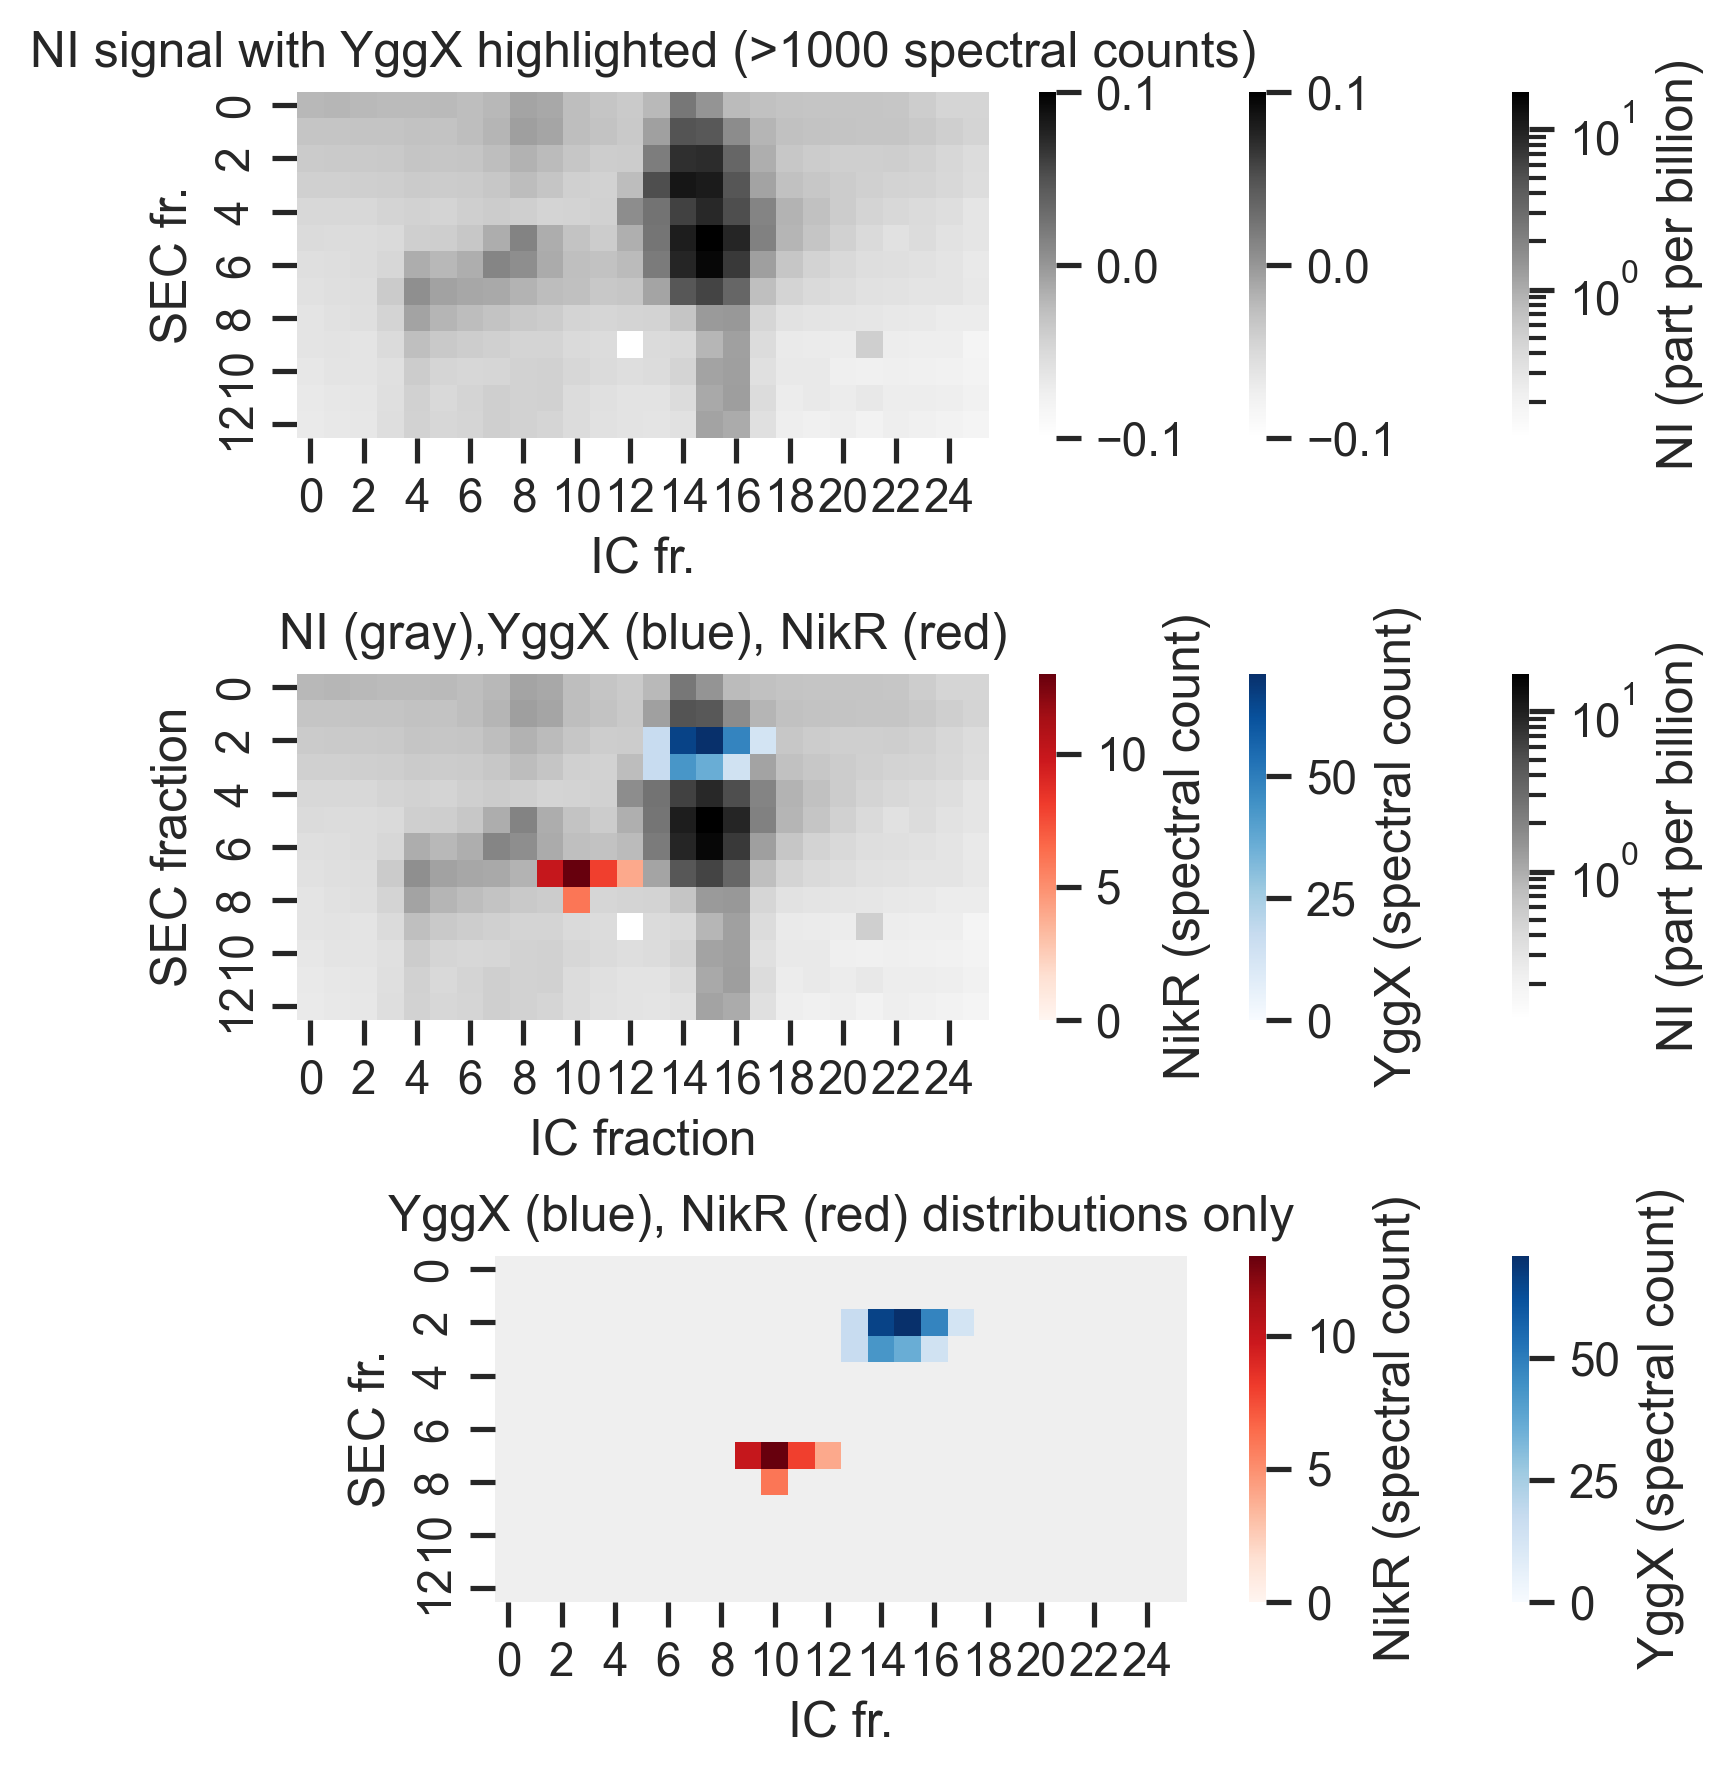

In [5]:
# Remove this line:
# plt.figure(figsize=(12, 6))

f, ax = plt.subplots(3,1, figsize=(6, 6))

gene = "YggX"
gene2 = "NikR"
metal = "60Ni"
metal_translated = isotope_element_mapping[metal]

# First subplot - ADD the third heatmap
sns.heatmap(metal_join_df.pivot(values=metal, index="x", on="y", )[:, 1:], cmap="Grays", square=True, cbar=True,
            norm=LogNorm(), cbar_kws={'label': f'{metal_translated} (part per billion)'}, ax=ax[0])
sns.heatmap(prot_df.pivot(values=gene, index="x", on="y", )[:, 1:], mask=(prot_df.pivot(values=gene,index="x", on="y", ) < 1000).to_numpy()[:, 1:],
            cmap="Grays", square=True, cbar=True, vmin=0,  cbar_kws={'label': f' '}, ax=ax[0])
# ADD THIS THIRD HEATMAP:
sns.heatmap(prot_df.pivot(values=gene, index="x", on="y", )[:, 1:], mask=(prot_df.pivot(values=gene, index="x", on="y",) < 1000).to_numpy()[:, 1:],
            cmap="Grays", square=True, cbar=True, vmin=0,  cbar_kws={'label': f' '}, ax=ax[0])

ax[0].set_ylabel("SEC fr.")
ax[0].set_xlabel("IC fr.")
ax[0].set_title(f"{metal_translated} signal with {gene} highlighted (>1000 spectral counts)")

# Second subplot stays the same
sns.heatmap(metal_join_df.pivot(values=metal, index="x", on="y", )[:, 1:], cmap="Grays", square=True,
            cbar=True, norm=LogNorm(), cbar_kws={'label': f'{metal_translated} (part per billion)'}, ax=ax[1])
sns.heatmap(prot_df.pivot(values=gene, index="x", on="y", )[:, 1:], mask=(prot_df.pivot(values=gene, index="x", on="y",) < 1).to_numpy()[:, 1:],
            cmap="Blues", square=True, cbar=True, vmin=0,  cbar_kws={'label': f'{gene} (spectral count)'}, ax=ax[1])
sns.heatmap(prot_df.pivot(values=gene2, index="x", on="y", )[:, 1:], mask=(prot_df.pivot(values=gene2, index="x", on="y",) < 1).to_numpy()[:, 1:],
            cmap="Reds", square=True, cbar=True, vmin=0,  cbar_kws={'label': f'{gene2} (spectral count)'}, ax=ax[1])

ax[1].set_ylabel("SEC fraction")
ax[1].set_xlabel("IC fraction")
ax[1].set_title(f"{metal_translated} (gray),{gene} (blue), {gene2} (red)")

# Third subplot - ADD the third heatmap
sns.heatmap(prot_df.pivot(values=gene, index="x", on="y", )[:, 1:], mask=(prot_df.pivot(values=gene, index="x", on="y", ) < 1).to_numpy()[:, 1:],
            cmap="Blues", square=True, cbar=True, vmin=0,  cbar_kws={'label': f'{gene} (spectral count)'}, ax=ax[2])
sns.heatmap(prot_df.pivot(values=gene2, index="x", on="y", )[:, 1:], mask=(prot_df.pivot(values=gene2, index="x", on="y",) < 1).to_numpy()[:, 1:],
            cmap="Reds", square=True, cbar=True, vmin=0,  cbar_kws={'label': f'{gene2} (spectral count)'}, ax=ax[2])


ax[2].set_ylabel("SEC fr.")
ax[2].set_xlabel("IC fr.")
ax[2].set_title(f"{gene} (blue), {gene2} (red) distributions only")
ax[2].grid(False)
ax[2].set_facecolor("#EFEFEF")

plt.tight_layout()

plt.savefig(f"/Users/adrianjuarez/Documents/Covert_lab/projects/Metals/YggX_figures/panelA.svg", 
            format='svg', bbox_inches='tight')
plt.savefig(f"/Users/adrianjuarez/Documents/Covert_lab/projects/Metals/YggX_figures/panelA.png", 
            format='png', bbox_inches='tight')

In [ ]:
g = sns.lmplot(x=gene, y="Isotope mass (ppb)", hue="Element", data=YggX_subset, 
               height=2.0, aspect=1,
               col="Element", col_order=element_order, col_wrap=4, 
               sharey=False, palette=element_palette,
               scatter_kws={"alpha": 0.6, "s": 20},
               line_kws={"linewidth": 1, "linestyle": "-"},
               legend=False)

# Annotation function
def annotate_slope_std(data, **kws):
    x = data[gene]
    y = data["Isotope mass (ppb)"]
    slope, intercept = np.polyfit(x, y, 1)
    resid_std = np.std(y - (slope * x + intercept))
    slope_std = resid_std / np.sqrt(np.sum((x - np.mean(x))**2))
    t = slope / slope_std
    p = 2 * (1 - stats.t.cdf(np.abs(t), df=len(x)-2))
    ax = plt.gca()
    ax.text(0.05, 0.90, f"slope = {slope:.4f}\nσ = {slope_std:.5f}, p={p:.5f}", 
            transform=ax.transAxes, fontsize=6, va="top")

# Apply annotations
g.map_dataframe(annotate_slope_std)

# Adjust labels
g.set_axis_labels(gene, "Isotope mass (ppb)", fontsize=10)
g.set_titles("{col_name}", fontsize=12)
g.fig.suptitle(f'{gene} spectral counts', fontsize=14, y=1.02)

# Save and show
# Make axes square and force zero onto both axes
for _ax in g.axes.flat:
    _ax.set_box_aspect(1)
    _x0, _x1 = _ax.get_xlim()
    _y0, _y1 = _ax.get_ylim()
    _ax.set_xlim(min(0, _x0), max(0, _x1))
    y_lo, y_hi = min(0, _y0), max(0, _y1)
    _ax.set_ylim(y_lo, y_hi + 0.38 * (y_hi - y_lo))  # top headroom for stats text

plt.savefig(f"/Users/adrianjuarez/Documents/Covert_lab/projects/Metals/YggX_figures/{gene}_isotope_correlations.svg", 
            format='svg', bbox_inches='tight')
plt.savefig(f"/Users/adrianjuarez/Documents/Covert_lab/projects/Metals/YggX_figures/{gene}_isotope_correlations.png", 
            format='png', bbox_inches='tight')

# normalized values 

In [ ]:
# Min-Max normalization (scales to 0-1 range)
YggX_subset_norm = YggX_subset.with_columns(
    ((pl.col("Isotope mass (ppb)") - pl.col("Isotope mass (ppb)").min().over("Element")) /
     (pl.col("Isotope mass (ppb)").max().over("Element") - pl.col("Isotope mass (ppb)").min().over("Element"))
    ).alias("Isotope mass(ppb)")
)

# Create the lmplot
g_norm = sns.lmplot(x=gene, y="Isotope mass(ppb)", hue="Element", data=YggX_subset_norm, 
                    height=2.0, aspect=1,
                    col="Element", col_order=element_order, col_wrap=4, 
                    sharey=False, palette=element_palette,
                    scatter_kws={"alpha": 0.6, "s": 20},
                    line_kws={"linewidth": 1, "linestyle": "-"},
                    legend=False)

# Annotation function
def annotate_slope_std_norm(data, **kws):
    x = data[gene]
    y = data["Isotope mass(ppb)"]
    slope, intercept = np.polyfit(x, y, 1)
    resid_std = np.std(y - (slope * x + intercept))
    slope_std = resid_std / np.sqrt(np.sum((x - np.mean(x))**2))
    t = slope / slope_std
    p = 2 * (1 - stats.t.cdf(np.abs(t), df=len(x)-2))
    ax = plt.gca()
    ax.text(0.05, 0.90, f"slope = {slope:.4f}\nσ = {slope_std:.5f}, p={p:.5f}", 
            transform=ax.transAxes, fontsize=6, va="top")

# Apply annotations
g_norm.map_dataframe(annotate_slope_std_norm)

# Adjust labels
g_norm.set_axis_labels(gene, "Isotope mass(ppb)", fontsize=10)
g_norm.set_titles("{col_name}", fontsize=12)
g_norm.fig.suptitle(f'{gene} feature scaled counts', fontsize=14, y=1.02)



# Save and show
# Make axes square and force zero onto both axes
for _ax in g_norm.axes.flat:
    _ax.set_box_aspect(1)
    _x0, _x1 = _ax.get_xlim()
    _y0, _y1 = _ax.get_ylim()
    _ax.set_xlim(min(0, _x0), max(0, _x1))
    y_lo, y_hi = min(0, _y0), max(0, _y1)
    _ax.set_ylim(y_lo, y_hi + 0.38 * (y_hi - y_lo))  # top headroom for stats text

plt.savefig(f"/Users/adrianjuarez/Documents/Covert_lab/projects/Metals/YggX_figures/{gene}_isotope_correlations_scaled.svg", 
            format='svg', bbox_inches='tight')
plt.savefig(f"/Users/adrianjuarez/Documents/Covert_lab/projects/Metals/YggX_figures/{gene}_isotope_correlations_scaled.png", 
            format='png', bbox_inches='tight')

In [8]:
def plot_normalized_metals_scatter(dataframe, metals, gene, element_palette, output_filename):
    metals_norm = (
        dataframe
        .filter(pl.col("Element").is_in(metals))
        .pivot(values="Isotope mass(ppb)", index=["x", "y", gene], on="Element")
        .drop_nulls(subset=metals)
    )

    metal_values = {metal: metals_norm[metal].to_numpy() for metal in metals}

    if len(metals) != 2:
        raise ValueError("This function currently supports only two metals for scatter plotting.")

    metal1, metal2 = metals
    slope, intercept, r, p, se = stats.linregress(metal_values[metal1], metal_values[metal2])

    # Create the scatter plot
    fig, ax = plt.subplots(figsize=(3, 3))
    ax.scatter(metal_values[metal1], metal_values[metal2], alpha=0.7, s=30, color=element_palette[metal2], edgecolors="none")
    x_line = np.linspace(metal_values[metal1].min(), metal_values[metal1].max(), 100)
    ax.plot(x_line, slope * x_line + intercept, color="gray", lw=1.5, linestyle="--")
    ax.set_xlabel(f"{metal1} (normalized)", fontsize=10)
    ax.set_ylabel(f"{metal2} (normalized)", fontsize=10)
    ax.set_title(f"{metal2} vs {metal1} (normalized spectral counts)", fontsize=10)
    ax.text(0.05, 0.95, f"r = {r:.3f}\np = {p:.3e}", transform=ax.transAxes, fontsize=8, va="top")
    
    # Make axes square and force zero onto both axes
    ax.set_box_aspect(1)
    _x0, _x1 = ax.get_xlim()
    _y0, _y1 = ax.get_ylim()
    ax.set_xlim(min(0, _x0), max(0, _x1))
    ax.set_ylim(min(0, _y0), max(0, _y1))

    sns.despine()
    plt.tight_layout()
plt.savefig(f"/Users/adrianjuarez/Documents/Covert_lab/projects/Metals/YggX_figures/panelD.svg", 
            format='svg', bbox_inches='tight')
plt.savefig(f"/Users/adrianjuarez/Documents/Covert_lab/projects/Metals/YggX_figures/panelD.png", 
            format='png', bbox_inches='tight')    
plt.show()

<Figure size 1920x1440 with 0 Axes>

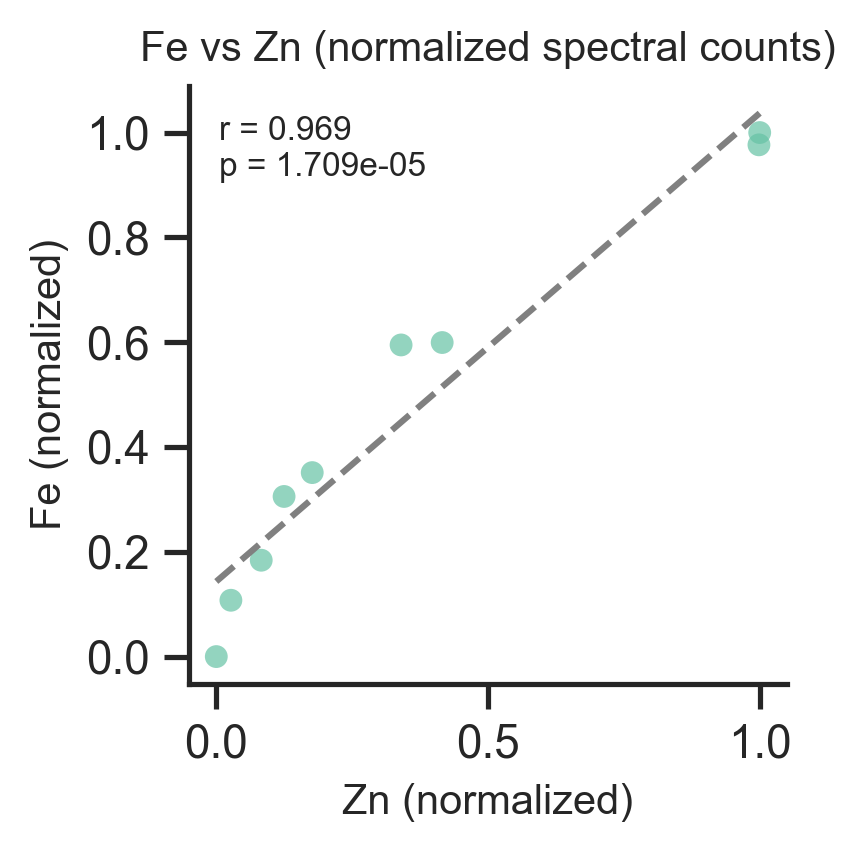

In [9]:
plot_normalized_metals_scatter(YggX_subset_norm, ["Zn", "Fe"], gene, element_palette, f"/Users/adrianjuarez/Documents/Covert_lab/projects/Metals/YggX_figures/{gene}_Fe_vs_Cr_normalized.svg")

# Avg signal (Zn, Fe, Mn) linear regression — all metals

In [10]:
# Pivot all 7 elements to wide format using the 0-1 normalized values from YggX_subset_norm
all_elements = ["Fe", "Zn", "Mn", "Cu", "Ni", "Co", "Cr"]

pivot_norm_all = (
    YggX_subset_norm
    .filter(pl.col("Element").is_in(all_elements))
    .pivot(values="Isotope mass(ppb)", index=["x", "y", gene], on="Element")
    .drop_nulls(subset=all_elements)
)

# avg_signal = mean of the 0-1 normalized Zn, Fe, Mn values per well
pivot_norm_all = pivot_norm_all.with_columns(
    avg_signal=((pl.col("Zn") + pl.col("Fe") + pl.col("Mn")) / 3)
)

In [ ]:
# Prepare data for all elements
plot_data_list = []
slopes = []
slope_ses = []
stats_dict = {}

for elem in element_order:
    df_pd = pivot_norm_all.select([gene, "avg_signal", elem]).to_pandas()
    df_pd.columns = ["YggX", "avg_signal", "metal"]

    X = df_pd[["YggX", "avg_signal"]].values
    y = df_pd["metal"].values

    model = LinearRegression()
    model.fit(X, y)
    y_pred = model.predict(X)
    r2 = model.score(X, y)
    X1, X2 = model.coef_

    n, p = X.shape
    residuals = y - y_pred
    MSE = np.sum(residuals ** 2) / (n - p - 1)
    X_aug = np.column_stack([np.ones(n), X])
    XtX_inv = np.linalg.inv(X_aug.T @ X_aug)
    SE_X1 = np.sqrt(MSE * XtX_inv[1, 1])

    slopes.append(X1)
    slope_ses.append(SE_X1)

    metal_corrected = y - X2 * df_pd["avg_signal"].values
    _, _, r_c, p_c, _ = stats.linregress(df_pd["YggX"].values, metal_corrected)

    # Store stats for annotation
    stats_dict[elem] = {"X1": X1, "r2": r2, "p_c": p_c}
    
    # Build combined dataframe
    plot_df = pd.DataFrame({
        "YggX": df_pd["YggX"], 
        "metal_corrected": metal_corrected,
        "Element": elem
    })
    plot_data_list.append(plot_df)

# Combine all data
combined_plot_data = pd.concat(plot_data_list, ignore_index=True)

# Create the lmplot
g = sns.lmplot(x="YggX", y="metal_corrected", hue="Element", data=combined_plot_data,
               height=2.0, aspect=1,
               col="Element", col_order=element_order, col_wrap=4,
               sharey=False, palette=element_palette,
               scatter_kws={"alpha": 0.6, "s": 20},
               line_kws={"linewidth": 1.5, "linestyle": "-"},
               legend=False)

# Annotation function
def annotate_stats(data, **kws):
    ax = plt.gca()
    elem = data["Element"].iloc[0]
    stats_info = stats_dict[elem]
    ax.text(0.05, 0.95,
            f"slope = {stats_info['X1']:.4f}\nR² = {stats_info['r2']:.3f}, p = {stats_info['p_c']:5f}",
            transform=ax.transAxes, fontsize=7, va="top")

# Apply annotations
g.map_dataframe(annotate_stats)

# Adjust labels
g.set_axis_labels("YggX counts", "predicted metal", fontsize=10)
g.set_titles("{col_name}", fontsize=10)

# Add suptitle
g.figure.suptitle("metal = X$_1$ * YggX - X$_2$*(Avg noise)", fontsize=11, y=1.02)

# Save and show
sns.despine()
plt.tight_layout()
# Make axes square and force zero onto both axes
for _ax in g.axes.flat:
    _ax.set_box_aspect(1)
    _x0, _x1 = _ax.get_xlim()
    _y0, _y1 = _ax.get_ylim()
    _ax.set_xlim(min(0, _x0), max(0, _x1))
    y_lo, y_hi = min(0, _y0), max(0, _y1)
    _ax.set_ylim(y_lo, y_hi + 0.38 * (y_hi - y_lo))  # top headroom for stats text

plt.savefig(f"/Users/adrianjuarez/Documents/Covert_lab/projects/Metals/YggX_figures/{gene}_metal_lr_avgAll_signal.svg", 
            format="svg", bbox_inches="tight")
plt.savefig(f"/Users/adrianjuarez/Documents/Covert_lab/projects/Metals/YggX_figures/{gene}_metal_lr_avgAll_signal.png", 
            format="png", bbox_inches="tight")
plt.show()

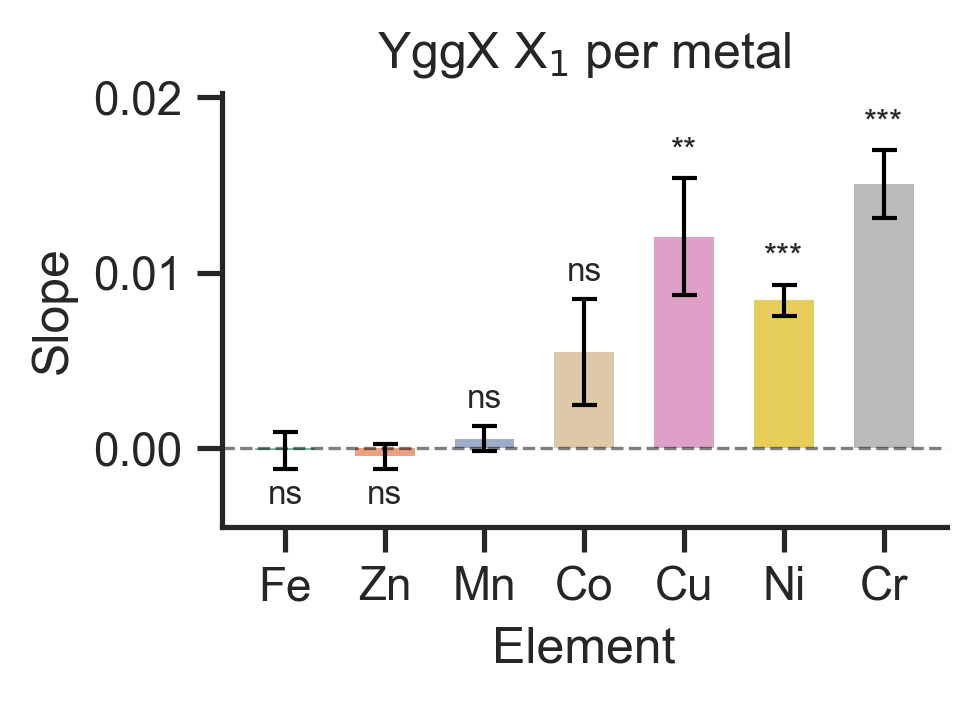

In [12]:
plot_data = pd.DataFrame({
    'Element': element_order,
    'Slope': slopes,
    'SE': slope_ses
})

# Create figure
fig, ax = plt.subplots(figsize=(3.5, 2.5))

# Create barplot with seaborn
sns.barplot(
    data=plot_data,
    x='Element',
    y='Slope',
    palette=element_palette,
    order=element_order,
    alpha=0.9,
    edgecolor="none",
    width=0.6,
    ax=ax
)

x_pos = np.arange(len(element_order))
ax.errorbar(
    x_pos, slopes, yerr=slope_ses,
    fmt="none", color="black", capsize=3, lw=1
)
_annotate_pstars(ax, x_pos, slopes, slope_ses,
                 [stats_dict[e]["p_c"] for e in element_order])

ax.axhline(0, color="black", lw=0.8, linestyle="--", alpha=0.5)

ax.set_xlabel("Element")
ax.set_ylabel("Slope")
ax.set_title("YggX X$_1$ per metal")



sns.despine()
plt.tight_layout()
plt.savefig(f"/Users/adrianjuarez/Documents/Covert_lab/projects/Metals/YggX_figures/panelE.svg", 
            format='svg', bbox_inches='tight')
plt.savefig(f"/Users/adrianjuarez/Documents/Covert_lab/projects/Metals/YggX_figures/panelE.png", 
            format='png', bbox_inches='tight') 
plt.show()

In [13]:
# Pivot all 7 elements to wide format using the 0-1 normalized values from YggX_subset_norm
all_elements = ["Fe", "Zn", "Mn", "Cu", "Ni", "Co", "Cr"]

pivot_norm_all = (
    YggX_subset_norm
    .filter(pl.col("Element").is_in(all_elements))
    .pivot(values="Isotope mass(ppb)", index=["x", "y", gene], on="Element")
    .drop_nulls(subset=all_elements)
)

# avg_signal = mean of the 0-1 normalized Zn, Fe, Mn values per well
pivot_norm_all = pivot_norm_all.with_columns(
    avg_signal=((pl.col("Zn") + pl.col("Fe") + pl.col("Mn") + pl.col("Cu") + pl.col("Ni") + pl.col("Co") + pl.col("Cr")) / 7)
)

In [ ]:
# Prepare data for all elements
plot_data_list = []
slopes = []
slope_ses = []
stats_dict = {}

for elem in element_order:
    df_pd = pivot_norm_all.select([gene, "avg_signal", elem]).to_pandas()
    df_pd.columns = ["YggX", "avg_signal", "metal"]

    X = df_pd[["YggX", "avg_signal"]].values
    y = df_pd["metal"].values

    model = LinearRegression()
    model.fit(X, y)
    y_pred = model.predict(X)
    r2 = model.score(X, y)
    X1, X2 = model.coef_

    # SE of X1 from multiple regression covariance matrix
    n, p = X.shape
    residuals = y - y_pred
    MSE = np.sum(residuals ** 2) / (n - p - 1)
    X_aug = np.column_stack([np.ones(n), X])
    XtX_inv = np.linalg.inv(X_aug.T @ X_aug)
    SE_X1 = np.sqrt(MSE * XtX_inv[1, 1])

    slopes.append(X1)
    slope_ses.append(SE_X1)

    metal_corrected = y - X2 * df_pd["avg_signal"].values
    _, _, r_c, p_c, _ = stats.linregress(df_pd["YggX"].values, metal_corrected)

    # Store stats for annotation
    stats_dict[elem] = {"X1": X1, "r2": r2, "p_c": p_c}
    
    # Build combined dataframe
    plot_df = pd.DataFrame({
        "YggX": df_pd["YggX"], 
        "metal_corrected": metal_corrected,
        "Element": elem
    })
    plot_data_list.append(plot_df)

# Combine all data
combined_plot_data = pd.concat(plot_data_list, ignore_index=True)

# Create the lmplot
g = sns.lmplot(x="YggX", y="metal_corrected", hue="Element", data=combined_plot_data,
               height=2.0, aspect=1,
               col="Element", col_order=element_order, col_wrap=4,
               sharey=False, palette=element_palette,
               scatter_kws={"alpha": 0.6, "s": 20},
               line_kws={"linewidth": 1.5, "linestyle": "-"},
               legend=False)

# Annotation function
def annotate_stats(data, **kws):
    ax = plt.gca()
    elem = data["Element"].iloc[0]
    stats_info = stats_dict[elem]
    ax.text(0.05, 0.95,
            f"slope = {stats_info['X1']:.4f}\nR² = {stats_info['r2']:.3f}, p = {stats_info['p_c']:5f}",
            transform=ax.transAxes, fontsize=7, va="top")

# Apply annotations
g.map_dataframe(annotate_stats)

# Adjust labels
g.set_axis_labels("YggX counts", "predicted metal", fontsize=10)
g.set_titles("{col_name}", fontsize=10)

# Add suptitle
g.figure.suptitle("metal = X$_1$ * YggX - X$_2$*(Avg noise)", fontsize=11, y=1.02)

# Save and show
sns.despine()
plt.tight_layout()
# Make axes square and force zero onto both axes
for _ax in g.axes.flat:
    _ax.set_box_aspect(1)
    _x0, _x1 = _ax.get_xlim()
    _y0, _y1 = _ax.get_ylim()
    _ax.set_xlim(min(0, _x0), max(0, _x1))
    y_lo, y_hi = min(0, _y0), max(0, _y1)
    _ax.set_ylim(y_lo, y_hi + 0.38 * (y_hi - y_lo))  # top headroom for stats text

plt.savefig(f"/Users/adrianjuarez/Documents/Covert_lab/projects/Metals/YggX_figures/{gene}_metal_lr_avgAll_signal.svg", 
            format="svg", bbox_inches="tight")
plt.savefig(f"/Users/adrianjuarez/Documents/Covert_lab/projects/Metals/YggX_figures/{gene}_metal_lr_avgAll_signal.png", 
            format="png", bbox_inches="tight")
plt.show()

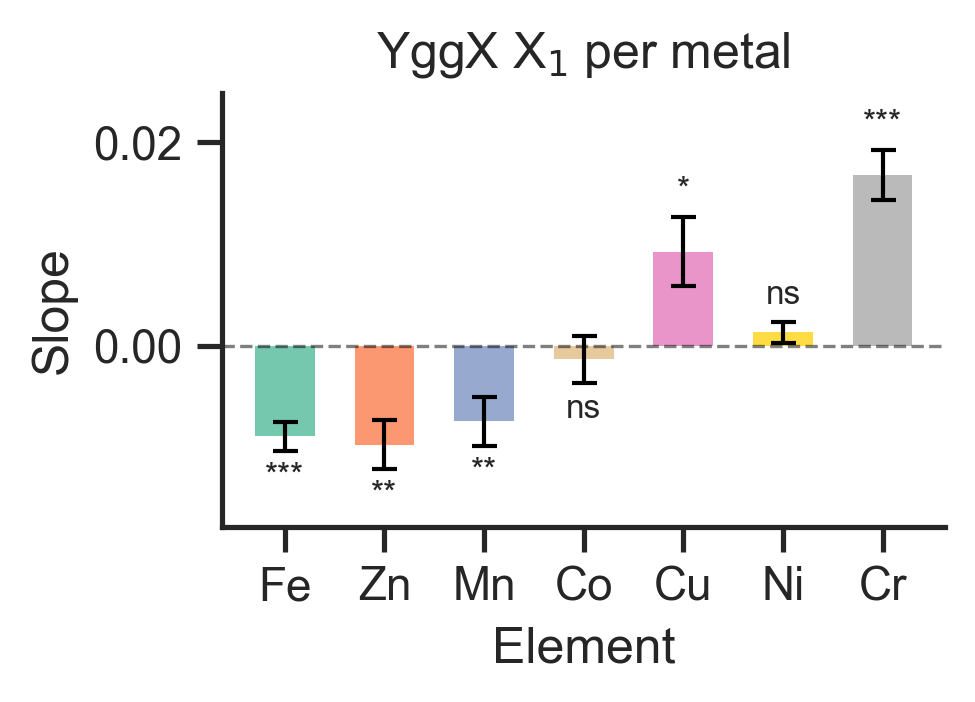

In [15]:
fig, ax = plt.subplots(figsize=(3.5, 2.5))

bar_colors = [element_palette[elem] for elem in element_order]
x_pos = np.arange(len(element_order))

ax.bar(x_pos, slopes, color=bar_colors, width=0.6, alpha=0.9,
       edgecolor="none")
ax.errorbar(x_pos, slopes, yerr=slope_ses,
            fmt="none", color="black", capsize=3, lw=1)
_annotate_pstars(ax, x_pos, slopes, slope_ses,
                 [stats_dict[e]["p_c"] for e in element_order])
ax.axhline(0, color="black", lw=0.8, linestyle="--", alpha=0.5)
ax.set_xticks(x_pos)
ax.set_xticklabels(element_order)
ax.set_xlabel("Element")
ax.set_ylabel("Slope")
ax.set_title("YggX X$_1$ per metal")

sns.despine()
plt.tight_layout()
plt.savefig(f"/Users/adrianjuarez/Documents/Covert_lab/projects/Metals/YggX_figures/panelF.svg", 
            format='svg', bbox_inches='tight')
plt.savefig(f"/Users/adrianjuarez/Documents/Covert_lab/projects/Metals/YggX_figures/panelF.png", 
            format='png', bbox_inches='tight') 
plt.show()

In [ ]:
# Pivot all 7 elements to wide format using raw (ppb) values from YggX_subset
pivot_raw_all = (
    YggX_subset
    .filter(pl.col("Element").is_in(all_elements))
    .pivot(values="Isotope mass (ppb)", index=["x", "y", gene], on="Element")
    .drop_nulls(subset=all_elements)
)

# avg_signal = mean of the raw Zn, Fe, Mn ppb values per well
pivot_raw_all = pivot_raw_all.with_columns(
    avg_signal=((pl.col("Zn") + pl.col("Fe") + pl.col("Mn")) / 3)
)

# Prepare data for all elements
plot_data_list_raw = []
slopes_raw = []
slope_ses_raw = []
stats_dict_raw = {}

for elem in element_order:
    df_pd = pivot_raw_all.select([gene, "avg_signal", elem]).to_pandas()
    df_pd.columns = ["YggX", "avg_signal", "metal"]

    X = df_pd[["YggX", "avg_signal"]].values
    y = df_pd["metal"].values

    model = LinearRegression()
    model.fit(X, y)
    y_pred = model.predict(X)
    r2 = model.score(X, y)
    X1, X2 = model.coef_

    n, p = X.shape
    residuals = y - y_pred
    MSE = np.sum(residuals ** 2) / (n - p - 1)
    X_aug = np.column_stack([np.ones(n), X])
    XtX_inv = np.linalg.inv(X_aug.T @ X_aug)
    SE_X1 = np.sqrt(MSE * XtX_inv[1, 1])

    slopes_raw.append(X1)
    slope_ses_raw.append(SE_X1)

    metal_corrected = y - X2 * df_pd["avg_signal"].values
    # Shift this element up so its minimum is >= 0 (removes negative values)
    metal_corrected = metal_corrected + max(-metal_corrected.min(), 0)
    _, _, r_c, p_c, _ = stats.linregress(df_pd["YggX"].values, metal_corrected)

    stats_dict_raw[elem] = {"X1": X1, "r2": r2, "p_c": p_c}

    plot_df = pd.DataFrame({
        "YggX": df_pd["YggX"],
        "metal_corrected": metal_corrected,
        "Element": elem
    })
    plot_data_list_raw.append(plot_df)

combined_plot_data_raw = pd.concat(plot_data_list_raw, ignore_index=True)

# Create the lmplot
g_raw = sns.lmplot(x="YggX", y="metal_corrected", hue="Element", data=combined_plot_data_raw,
                   height=2.0, aspect=1,
                   col="Element", col_order=element_order, col_wrap=4,
                   sharey=False, palette=element_palette,
                   scatter_kws={"alpha": 0.6, "s": 20},
                   line_kws={"linewidth": 1.5, "linestyle": "-"},
                   legend=False)

def annotate_stats_raw(data, **kws):
    ax = plt.gca()
    elem = data["Element"].iloc[0]
    stats_info = stats_dict_raw[elem]
    ax.text(0.05, 0.95,
            f"slope = {stats_info['X1']:.4f}\nR² = {stats_info['r2']:.3f}, p = {stats_info['p_c']:5f}",
            transform=ax.transAxes, fontsize=7, va="top")

g_raw.map_dataframe(annotate_stats_raw)

g_raw.set_axis_labels("YggX spectral counts", "metal ppb (noise-corrected)", fontsize=10)
g_raw.set_titles("{col_name}", fontsize=10)
g_raw.figure.suptitle("metal (ppb) = X$_1$ * YggX - X$_2$*(Avg noise)", fontsize=11, y=1.02)

sns.despine()
plt.tight_layout()
# Make axes square and force zero onto both axes
for _ax in g_raw.axes.flat:
    _ax.set_box_aspect(1)
    _x0, _x1 = _ax.get_xlim()
    _y0, _y1 = _ax.get_ylim()
    _ax.set_xlim(min(0, _x0), max(0, _x1))
    y_lo, y_hi = min(0, _y0), max(0, _y1)
    _ax.set_ylim(y_lo, y_hi + 0.38 * (y_hi - y_lo))  # top headroom for stats text

plt.savefig(f"/Users/adrianjuarez/Documents/Covert_lab/projects/Metals/YggX_figures/{gene}_metal_lr_avgAll_signal_raw.svg",
            format="svg", bbox_inches="tight")
plt.savefig(f"/Users/adrianjuarez/Documents/Covert_lab/projects/Metals/YggX_figures/{gene}_metal_lr_avgAll_signal_raw.png",
            format="png", bbox_inches="tight")
plt.show()

# --- Slope barplots, split into two element groups to show the different
# y-scales clearly. Fe/Zn/Mn/Co appear in both as a shared reference. ---
slope_by_elem = dict(zip(element_order, slopes_raw))
se_by_elem = dict(zip(element_order, slope_ses_raw))

group1 = ["Fe", "Zn", "Mn", "Co", "Cu", "Ni"]
group2 = ["Fe", "Zn", "Mn", "Co", "Cr"]

FIG_DIR = "/Users/adrianjuarez/Documents/Covert_lab/projects/Metals/YggX_figures"


def _draw_slope_bars(ax, elems, title, pvals):
    x = np.arange(len(elems))
    slopes = [slope_by_elem[e] for e in elems]
    ses = [se_by_elem[e] for e in elems]
    colors = [element_palette[e] for e in elems]
    ax.bar(x, slopes, color=colors, width=0.6, alpha=0.9, edgecolor="none")
    ax.errorbar(x, slopes, yerr=ses, fmt="none", color="black", capsize=3, lw=1)
    _annotate_pstars(ax, x, slopes, ses, pvals)
    ax.axhline(0, color="black", lw=0.8, linestyle="--", alpha=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(elems)
    ax.set_xlabel("Element")
    ax.set_ylabel("Slope (X$_1$)")
    ax.set_title(title)
    sns.despine(ax=ax)

# (2) Two entirely separate figures, one per group
for grp, tag, subtitle in [
    (group1, "group1", "Fe, Zn, Mn, Co, Cu, Ni"),
    (group2, "group2", "Fe, Zn, Mn, Co, Cr"),
]:
    fig, ax = plt.subplots(figsize=(3.5, 2.5))
    _draw_slope_bars(ax, grp, f"{gene} Slope per raw metal count",
                     [stats_dict_raw[e]["p_c"] for e in grp])
    plt.tight_layout()
    for ext in ("svg", "png"):
        plt.savefig(f"{FIG_DIR}/{gene}_metal_slopes_barplot_raw_{tag}.{ext}",
                    format=ext, bbox_inches="tight")
    plt.show()

# begin rnaSeq work here

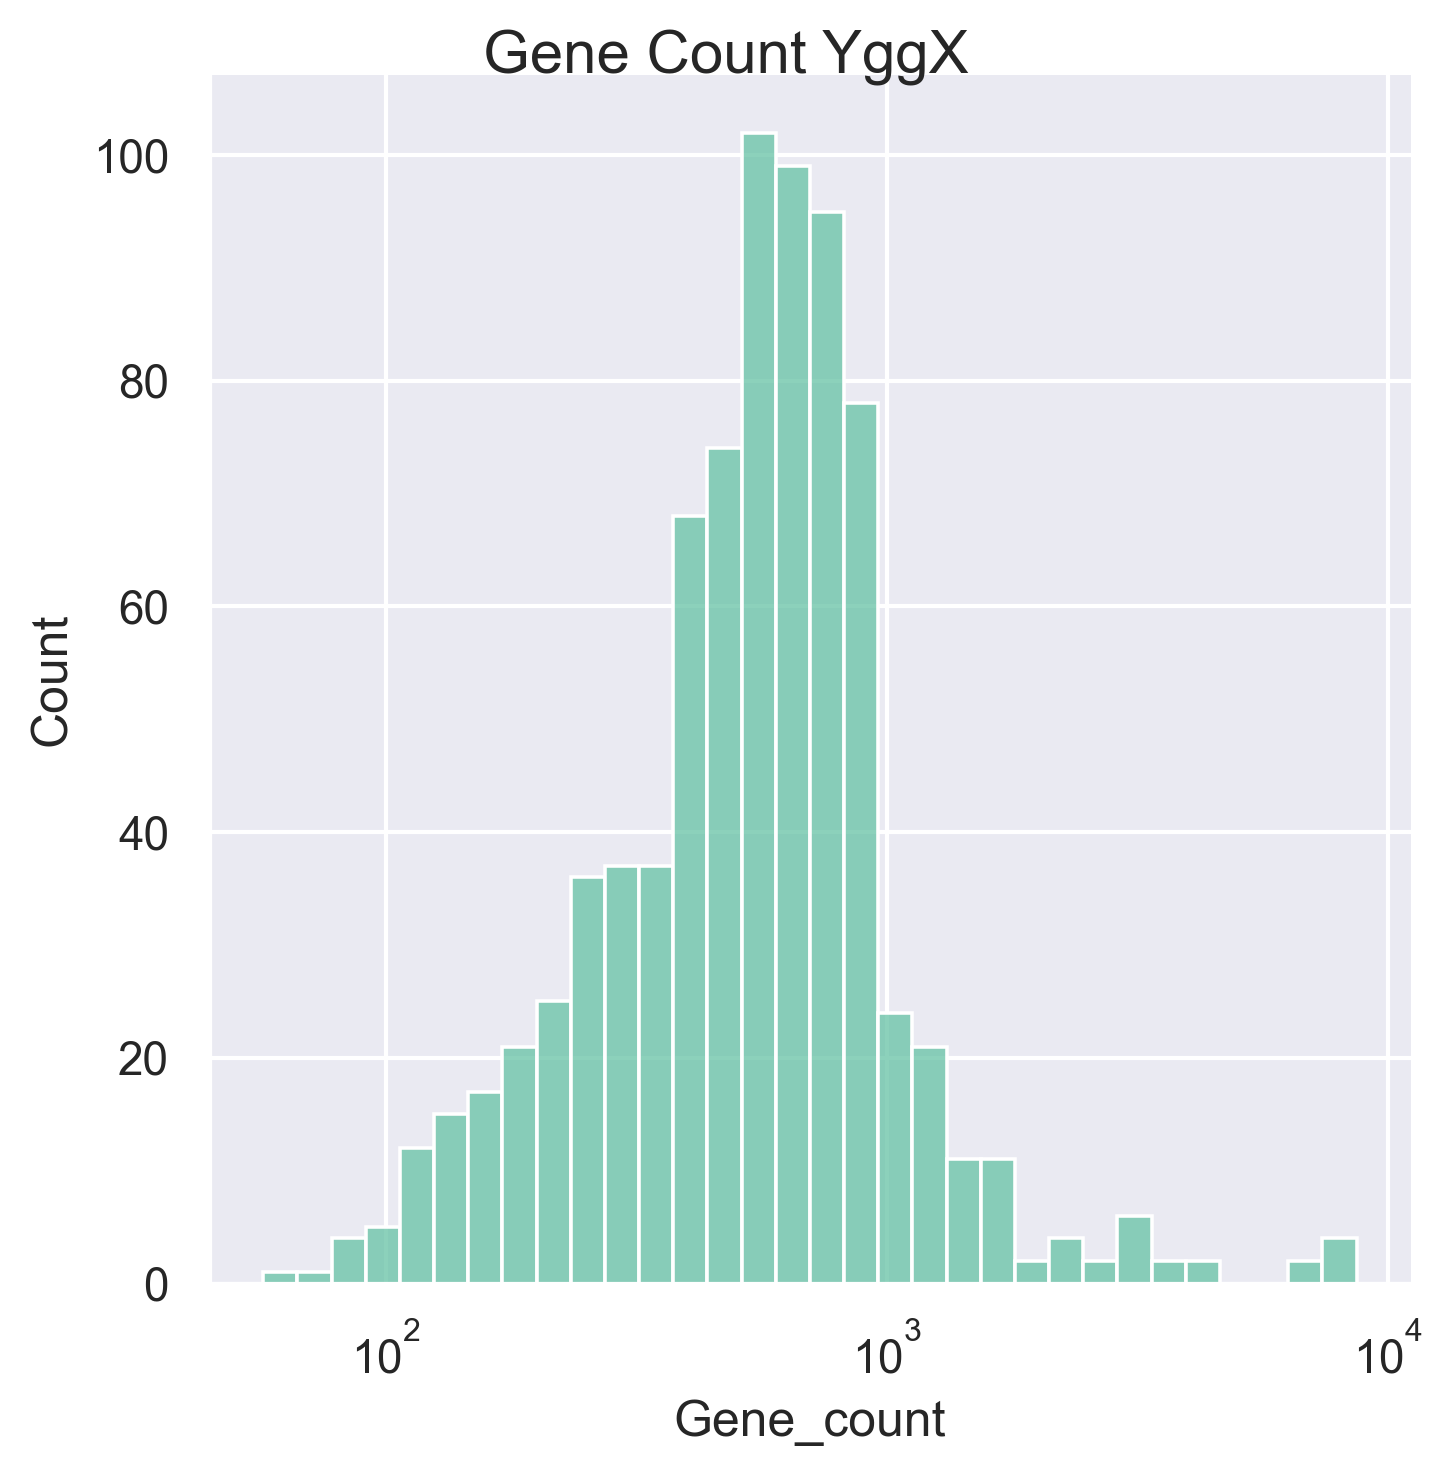

In [17]:
mpl.rcParams['figure.dpi'] = 300
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

GENE_INFO_PATH = "/Users/adrianjuarez/Documents/Covert_lab/repos/precise2/data/precise2/gene_info.csv"
GENE_ID = "b2962"

sns.set(style="ticks", palette="Set2", context="notebook",
        rc={"axes.formatter.limits": (-3, 3)})
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42
m = pl.read_csv("/Users/adrianjuarez/Documents/Covert_lab/repos/precise2/data/precise2/metadata.tsv", separator="\t")
d = pl.read_csv("/Users/adrianjuarez/Documents/Covert_lab/repos/precise2/data/precise2/counts.csv")
gene_info = pl.read_csv(GENE_INFO_PATH)
cols = ['Experiment', 'study', 'condition_id', 'rep_id', 'creator', 'run_date', 'Strain Description', 
 'Base Media', 'Carbon Source (g/L)', 'Nitrogen Source (g/L)', 'Electron Acceptor', 'Trace Element Mixture', 
 'Supplement', 'Temperature (C)', 'pH', 'Growth Rate (1/hr)']

sns.set(style="darkgrid", palette="Set2")

pl.Config(tbl_rows=30)
# melt data
dm = d.melt(id_vars="Geneid", variable_name="Experiment", value_name="Gene_count")
dj = dm.join(m, on="Experiment", how="left", coalesce=True)

cols = ['Experiment', 'Geneid', 'Gene_count', 'study', 'condition_id', 'rep_id', 'creator', 'run_date', 'Strain Description', 
 'Base Media', 'Carbon Source (g/L)', 'Nitrogen Source (g/L)', 'Electron Acceptor', 'Trace Element Mixture', 
 'Supplement', 'Temperature (C)', 'pH', 'Growth Rate (1/hr)']

dj.select(cols)
g = sns.displot(x='Gene_count', data = dj.filter(pl.col('Geneid')==GENE_ID).to_pandas(), 
                log_scale=[10,False], common_norm=False, legend=True)
g.fig.subplots_adjust(top=0.95)  # Make room for title
g.fig.suptitle(f'Gene Count {gene}')
plt.savefig("gene_count.png", bbox_inches="tight")


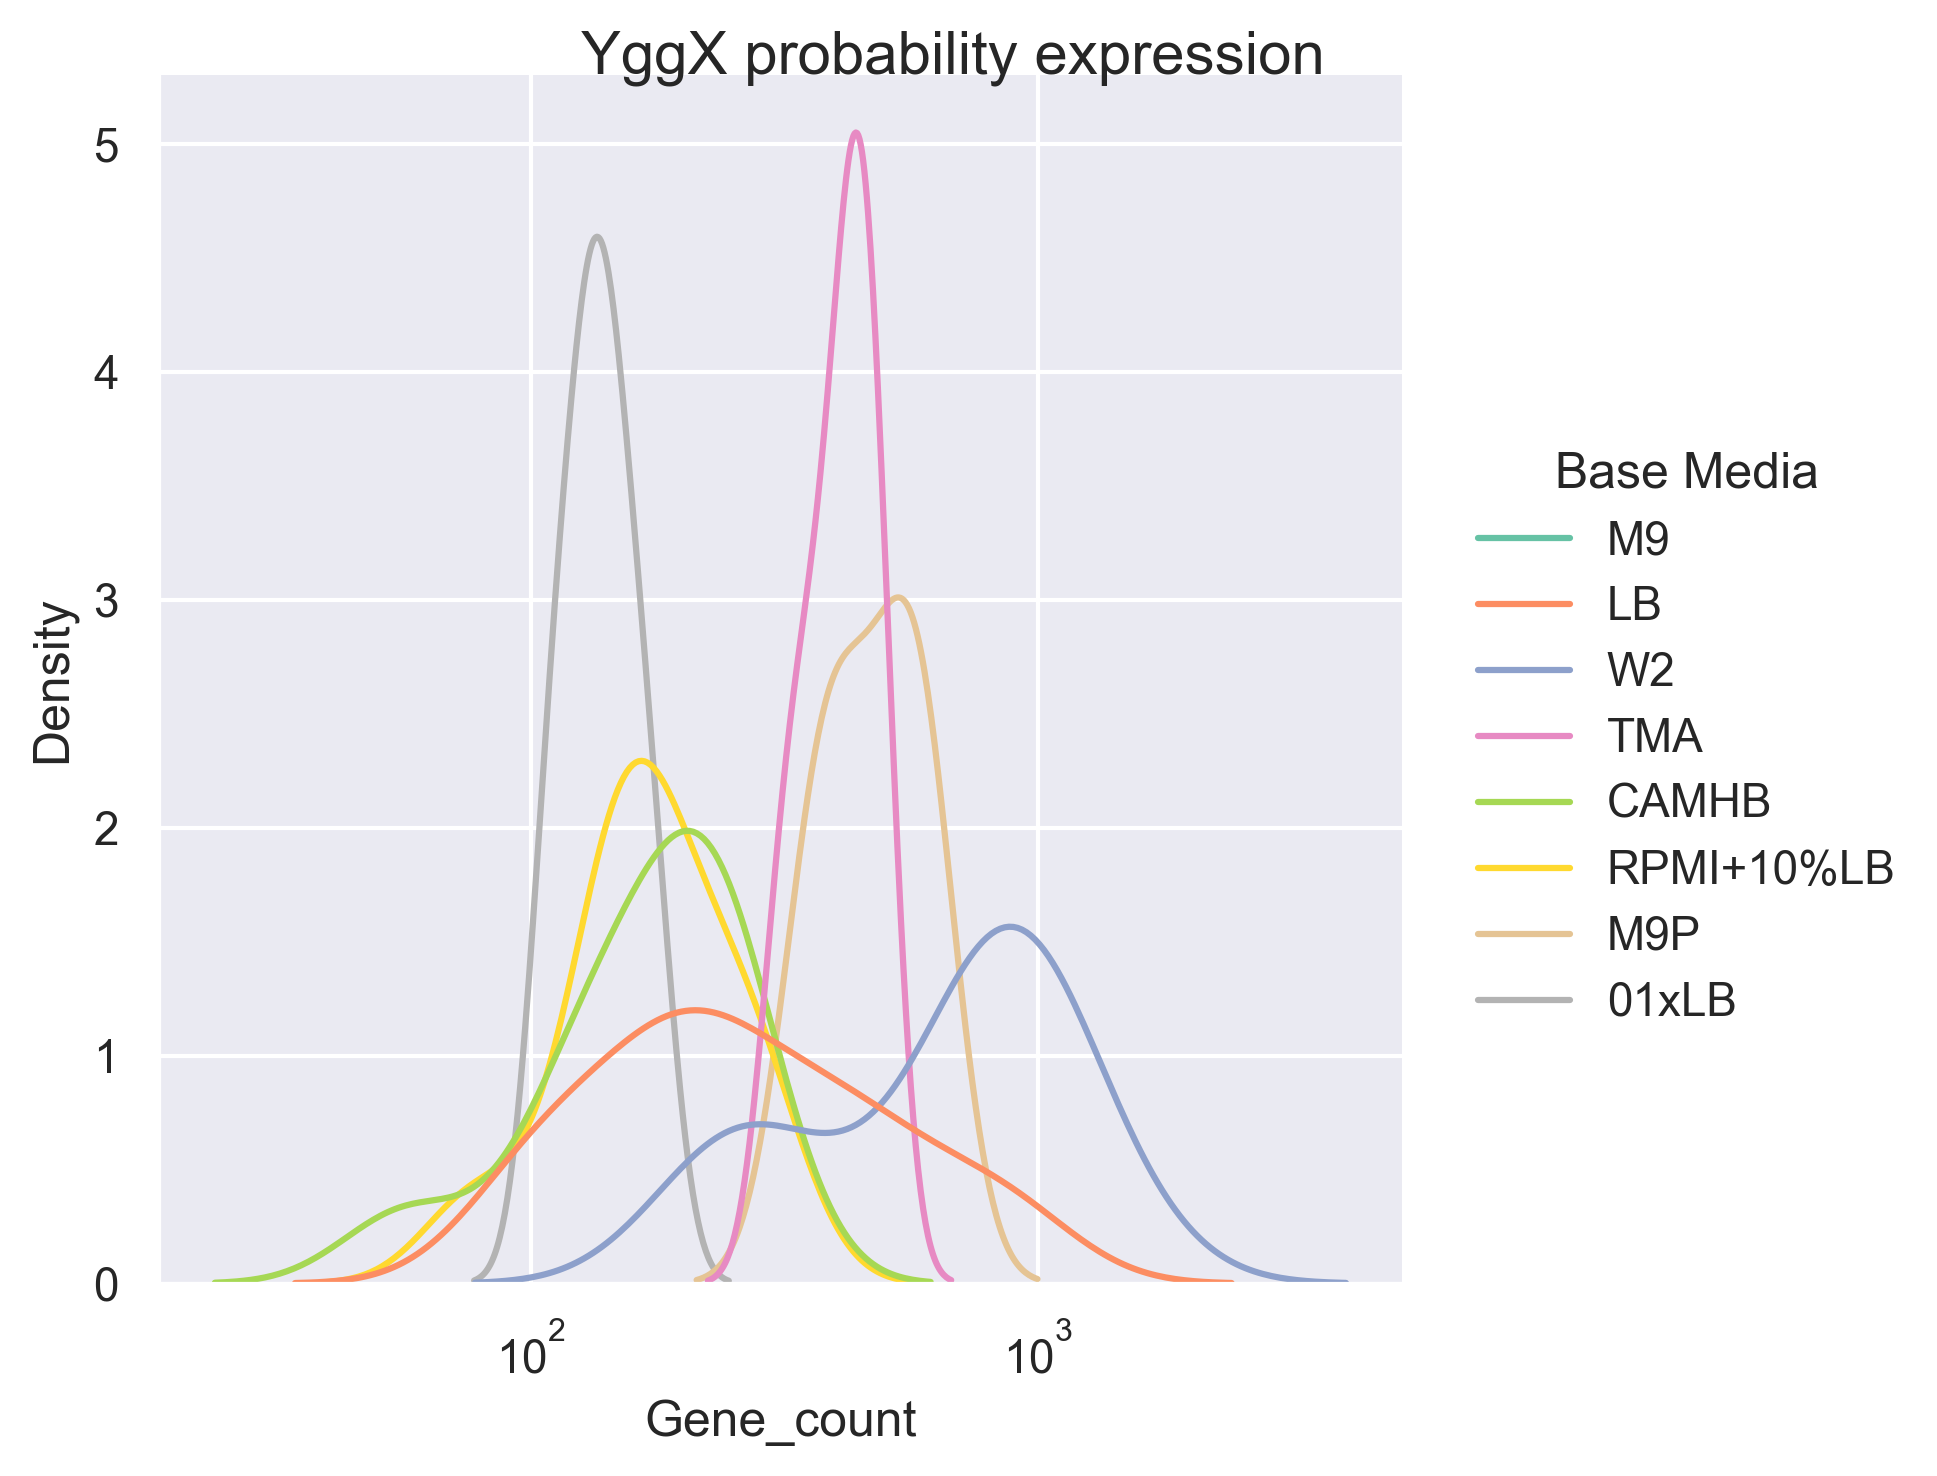

In [18]:
g2 = sns.displot(x='Gene_count', data = dj.filter(pl.col('Geneid')==GENE_ID).to_pandas(), 
            kind='kde', log_scale=[10,False], hue='Base Media', common_norm=False)

g2.fig.subplots_adjust(top=0.95)  # Make room for title
g2.fig.suptitle(f'{gene} probability expression')
plt.savefig("YggX_expression_density.png", bbox_inches="tight")


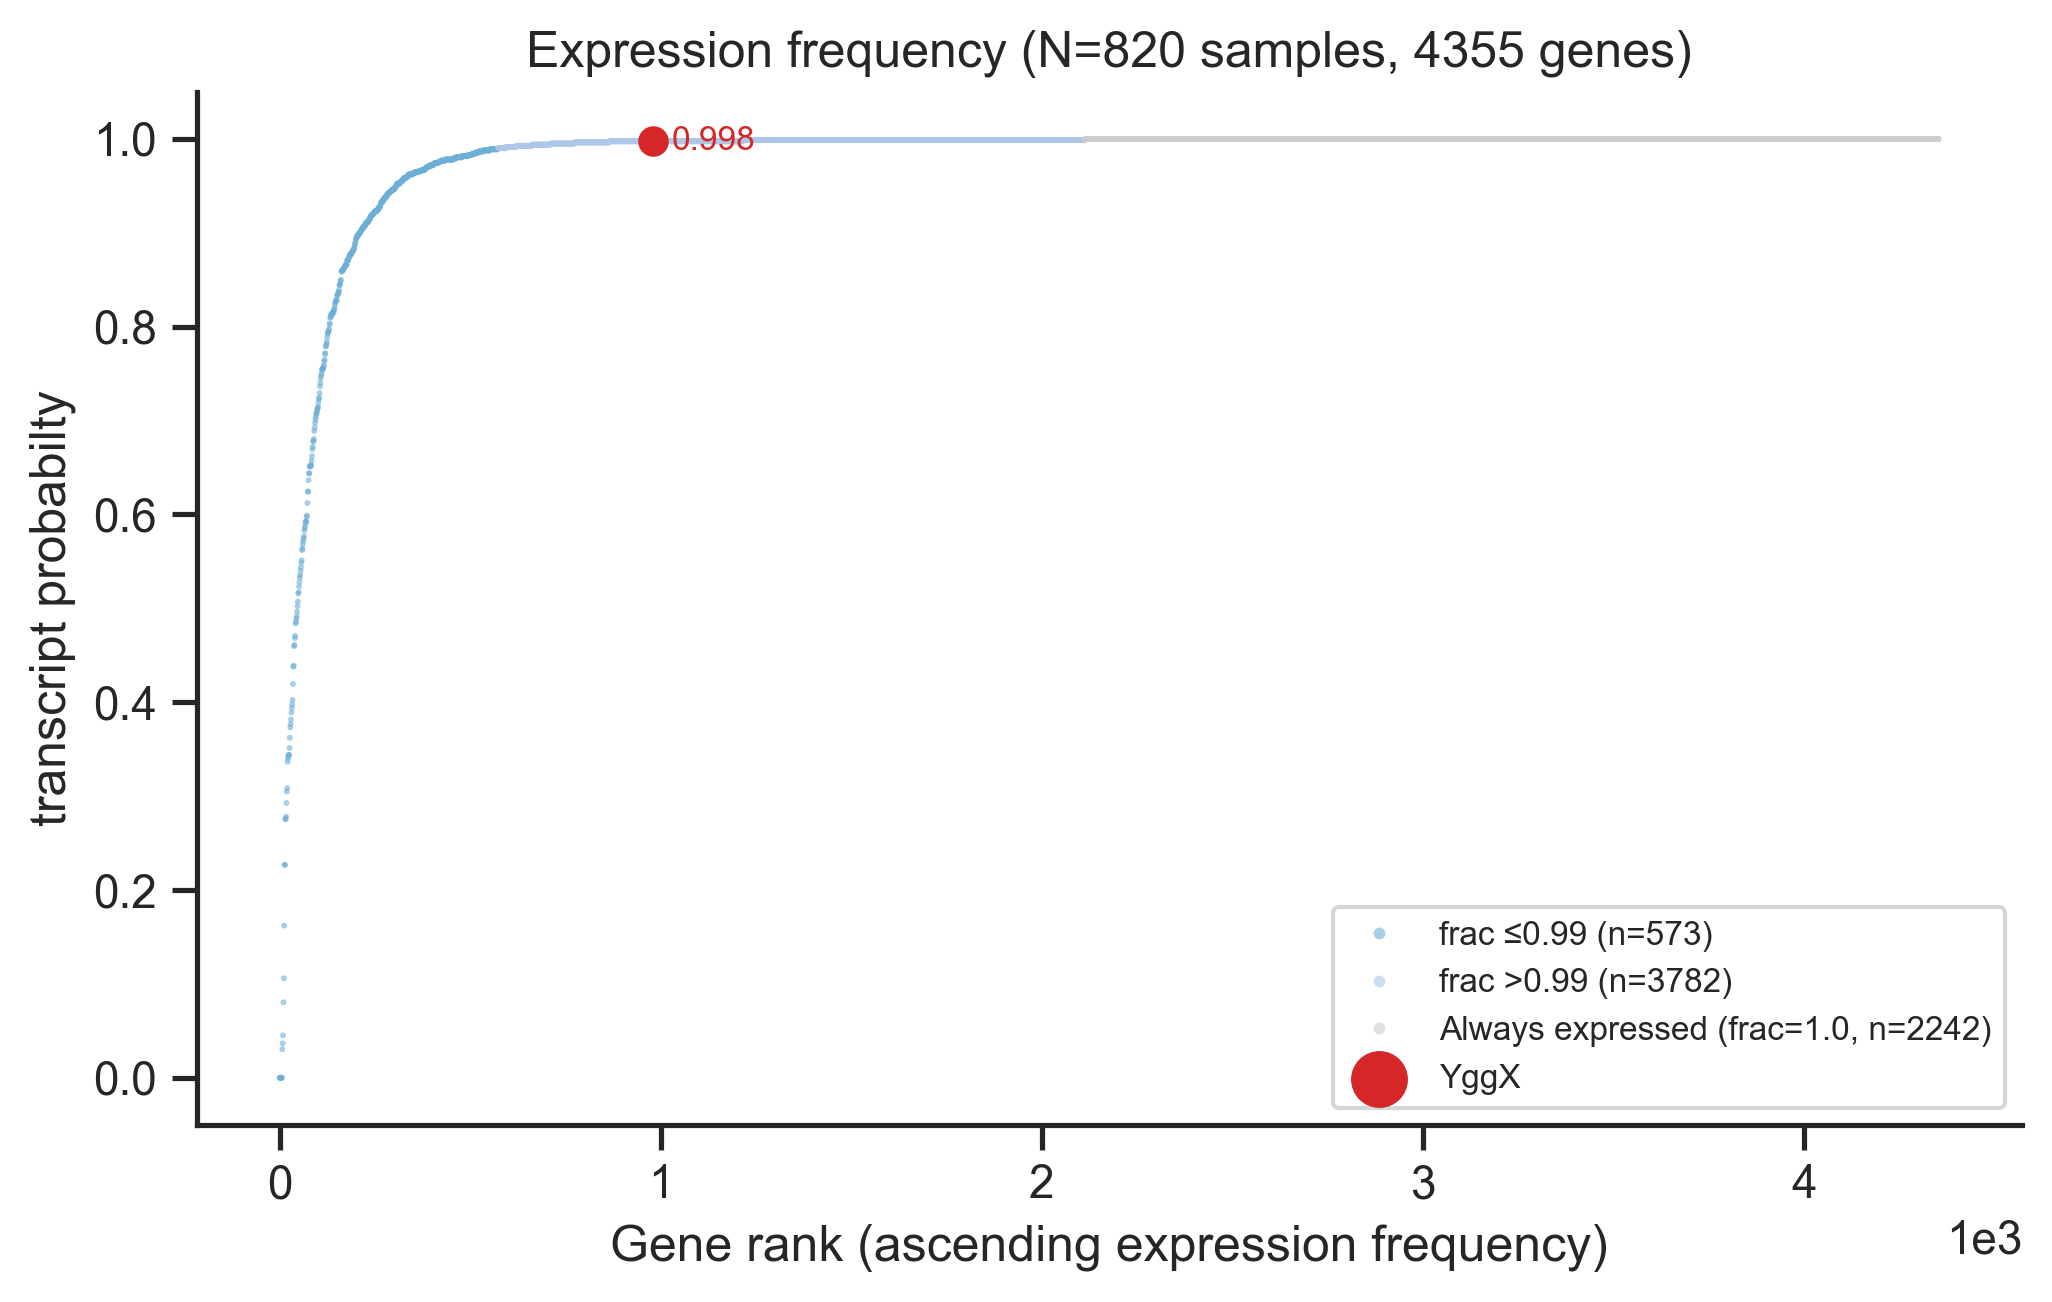

In [19]:
COUNTS_PATH = "/Users/adrianjuarez/Documents/Covert_lab/repos/precise2/data/precise2/counts.csv"

sns.set(style="ticks", palette="Set2", context="notebook",
        rc={"axes.formatter.limits": (-3, 3)})
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

d = pl.read_csv(COUNTS_PATH)
count_cols = d.columns[1:]
expr_matrix = d.select(count_cols).to_numpy()
gene_ids = d["Geneid"].to_list()

frac_expressed = (expr_matrix > 0).mean(axis=1)
GENE_ID = "b2962"
YggX_idx = gene_ids.index(GENE_ID)
YggX_frac = frac_expressed[YggX_idx]

sort_order = np.argsort(frac_expressed)
YggX_rank = int(np.where(sort_order == YggX_idx)[0][0])
n_genes = len(frac_expressed)
frac_sorted = frac_expressed[sort_order]

# Create a dataframe for seaborn
plot_df = pd.DataFrame({
    'rank': np.arange(n_genes),
    'fraction': frac_sorted,
    'category': np.where(frac_sorted == 1.0, f"Always expressed (frac=1.0, n={(frac_expressed==1.0).sum()})",
                np.where(frac_sorted > 0.99, f"frac >0.99 (n={(frac_expressed>0.99).sum()})",
                        f"frac ≤0.99 (n={(frac_expressed<=0.99).sum()})"))
})

fig, ax = plt.subplots(figsize=(7, 4.5))

# Define color palette
palette = {
    f"Always expressed (frac=1.0, n={(frac_expressed==1.0).sum()})": "#cccccc",
    f"frac >0.99 (n={(frac_expressed>0.99).sum()})": "#aec6e8",
    f"frac ≤0.99 (n={(frac_expressed<=0.99).sum()})": "#6baed6",
    "YggX": "#d62728"
}

# Plot background genes with seaborn
sns.scatterplot(data=plot_df, x='rank', y='fraction', hue='category',
                palette=palette, s=2, alpha=0.6, linewidth=0, ax=ax, legend='full')

# Add YggX point separately with larger size
ax.scatter(YggX_rank, YggX_frac, color="#d62728", s=40, zorder=5, label='YggX')

ax.text(YggX_rank + 50, YggX_frac, f"{YggX_frac:.3f}",
        fontsize=8, color="#d62728", va="center")

# Recreate legend to include YggX
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles, labels=labels, fontsize=8, loc="lower right", markerscale=2)

ax.set_xlabel("Gene rank (ascending expression frequency)")
ax.set_ylabel("transcript probabilty")
ax.set_title(f"Expression frequency (N=820 samples, {n_genes} genes)")
sns.despine(ax=ax)

plt.tight_layout()
plt.savefig("YggX_expression_frequency_rank.png", bbox_inches="tight")
plt.show()

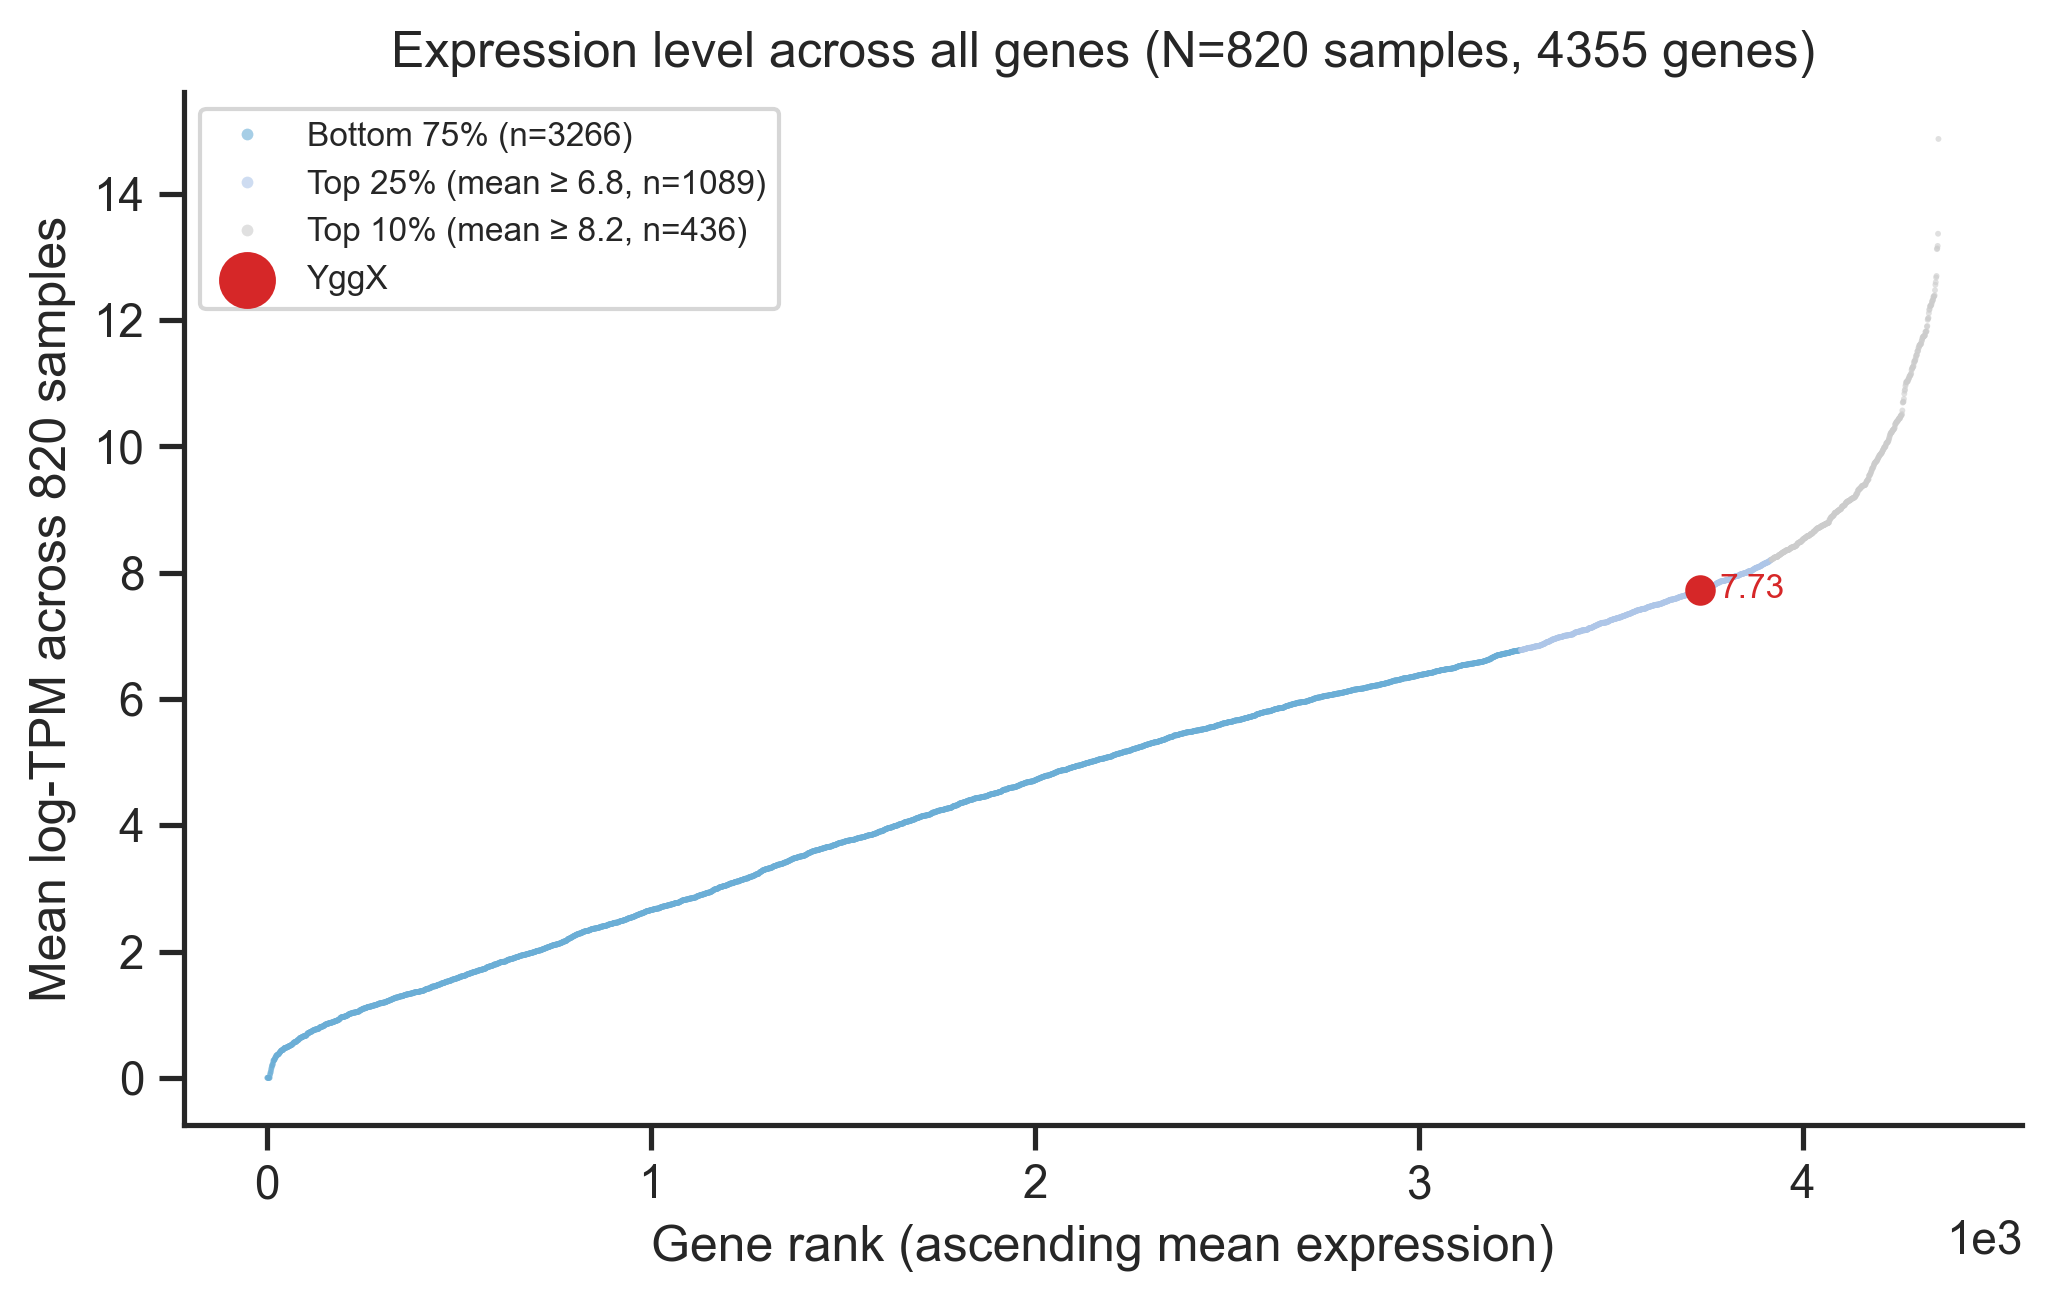

In [20]:
LOG_TPM_PATH = "/Users/adrianjuarez/Documents/Covert_lab/repos/precise2/data/precise2/log_tpm.csv"
YggX_ID = "b2962"

sns.set(style="ticks", palette="Set2", context="notebook",
        rc={"axes.formatter.limits": (-3, 3)})
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

d = pl.read_csv(LOG_TPM_PATH)
count_cols = d.columns[1:]
expr_matrix = d.select(count_cols).to_numpy()
gene_ids = d["Geneid"].to_list()

mean_expr = expr_matrix.mean(axis=1)  # mean log-TPM across all 820 samples

YggX_idx = gene_ids.index(YggX_ID)
YggX_mean = mean_expr[YggX_idx]

sort_order = np.argsort(mean_expr)
YggX_rank = int(np.where(sort_order == YggX_idx)[0][0])
n_genes = len(mean_expr)
mean_sorted = mean_expr[sort_order]

# Colour tiers by expression level
p75 = np.percentile(mean_expr, 75)
p90 = np.percentile(mean_expr, 90)

# Create a dataframe for seaborn
plot_df = pd.DataFrame({
    'rank': np.arange(n_genes),
    'mean_expr': mean_sorted,
    'category': np.where(mean_sorted >= p90, f"Top 10% (mean ≥ {p90:.1f}, n={int((mean_expr>=p90).sum())})",
                np.where(mean_sorted >= p75, f"Top 25% (mean ≥ {p75:.1f}, n={int((mean_expr>=p75).sum())})",
                        f"Bottom 75% (n={int((mean_expr<p75).sum())})"))
})

fig, ax = plt.subplots(figsize=(7, 4.5))

# Define color palette
palette = {
    f"Top 10% (mean ≥ {p90:.1f}, n={int((mean_expr>=p90).sum())})": "#cccccc",
    f"Top 25% (mean ≥ {p75:.1f}, n={int((mean_expr>=p75).sum())})": "#aec6e8",
    f"Bottom 75% (n={int((mean_expr<p75).sum())})": "#6baed6",
    "YggX": "#d62728"
}

# Plot background genes with seaborn
sns.scatterplot(data=plot_df, x='rank', y='mean_expr', hue='category',
                palette=palette, s=2, alpha=0.6, linewidth=0, ax=ax, legend='full')

# Add YggX point separately with larger size
ax.scatter(YggX_rank, YggX_mean, color="#d62728", s=40, zorder=5, label='YggX')

ax.text(YggX_rank + 50, YggX_mean, f"{YggX_mean:.2f}",
        fontsize=8, color="#d62728", va="center")

# Recreate legend to include YggX
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles, labels=labels, fontsize=8, loc="upper left", markerscale=2)

ax.set_xlabel("Gene rank (ascending mean expression)")
ax.set_ylabel("Mean log-TPM across 820 samples")
ax.set_title(f"Expression level across all genes (N=820 samples, {n_genes} genes)")
sns.despine(ax=ax)

plt.tight_layout()
plt.savefig("YggX_expression_level_rank.png", bbox_inches="tight")
plt.show()

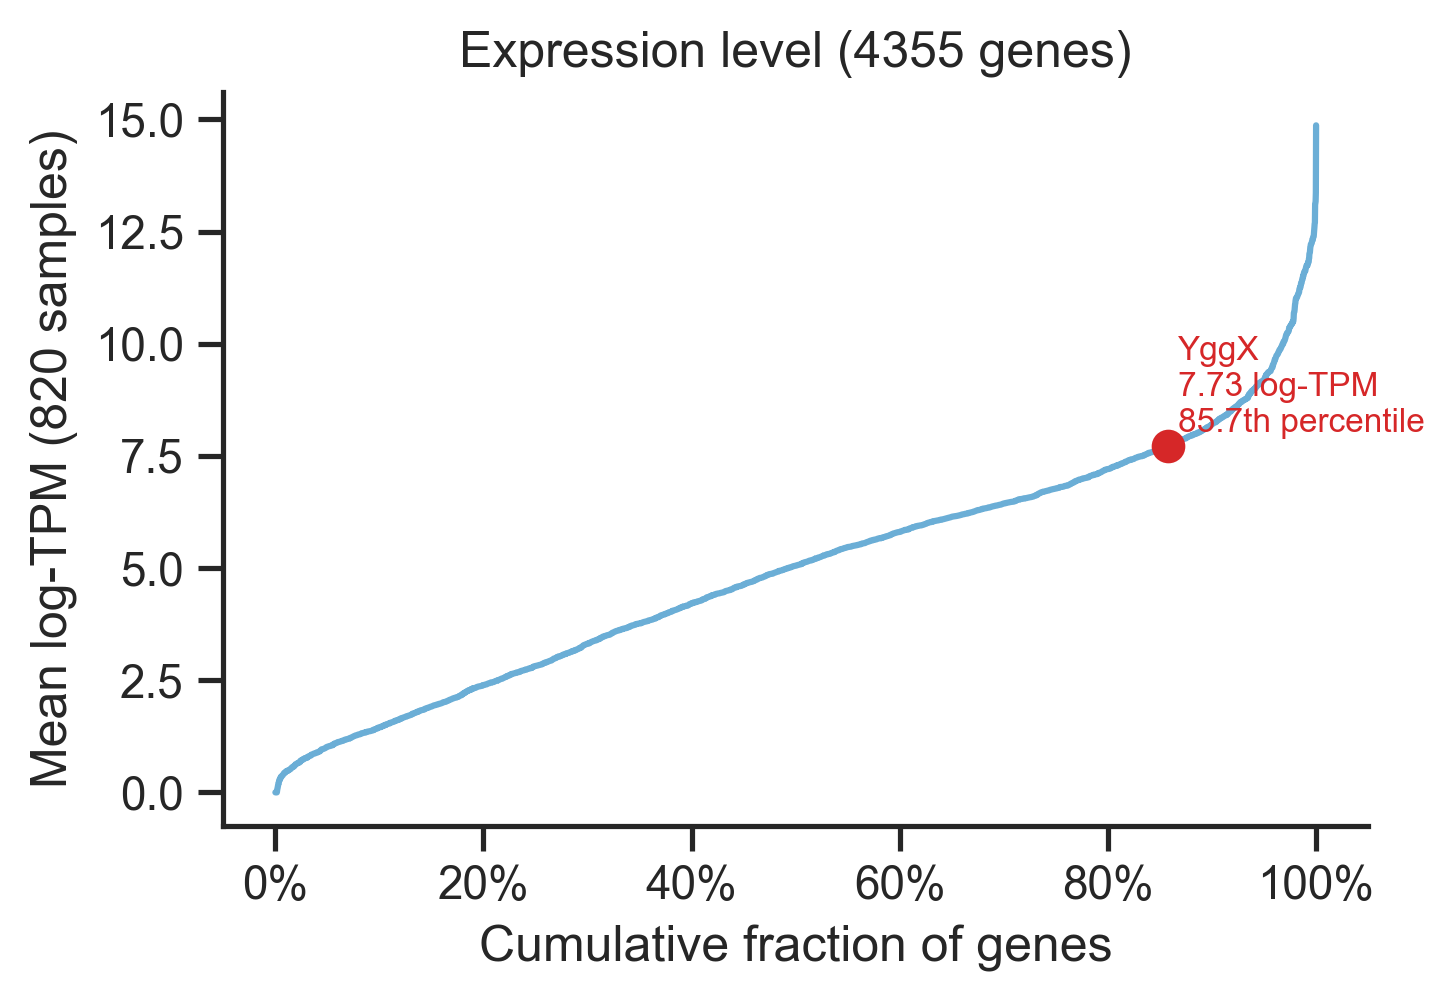

In [21]:
YggX_percentile = float(np.mean(mean_expr <= YggX_mean)) * 100

fig, ax = plt.subplots(figsize=(5, 3.5))

sorted_expr = np.sort(mean_expr)
ecdf_y = np.arange(1, n_genes + 1) / n_genes

ax.plot(ecdf_y, sorted_expr, color="#6baed6", lw=1.5, label="all genes")

ax.scatter([YggX_percentile / 100], [YggX_mean], color="#d62728", s=50, zorder=5)

ax.text(YggX_percentile / 100 + 0.01, YggX_mean + 0.15,
        f"YggX\n{YggX_mean:.2f} log-TPM\n{YggX_percentile:.1f}th percentile",
        fontsize=8, color="#d62728", va="bottom")

ax.set_xlabel("Cumulative fraction of genes")
ax.set_ylabel("Mean log-TPM (820 samples)")
ax.set_title(f"Expression level ({n_genes} genes)")
ax.xaxis.set_major_formatter(mpl.ticker.PercentFormatter(xmax=1, decimals=0))

sns.despine(ax=ax)
plt.tight_layout()
plt.savefig("YggX_expression_ecdf.png", bbox_inches="tight")
plt.show()

In [22]:
# Build YggX log-TPM long-form dataframe joined with metadata
# Reuses d (log_tpm), m (metadata), and YggX_ID already loaded above
YggX_long = (
    d.filter(pl.col("Geneid") == YggX_ID)
    .melt(id_vars="Geneid", variable_name="Experiment", value_name="log_tpm")
    .join(
        m.select(["Experiment", "Base Media", "Electron Acceptor", "study",
                  "Growth Rate (1/hr)"]),
        on="Experiment", how="left", coalesce=True,
    )
    .drop("Geneid")
)


def _build_expr_summary(long_df, group_col):
    """Compute mean ± stdev of log-TPM per group, sorted descending by mean."""
    rows = []
    for (grp,), sub in long_df.group_by([group_col]):
        vals = sub["log_tpm"].drop_nulls().to_numpy()
        if len(vals) == 0:
            continue
        rows.append({"Group": str(grp), "Mean": float(vals.mean()), "Stdev": float(vals.std())})
    return (
        pl.DataFrame(rows)
        .sort("Mean", descending=True)
        .with_row_index("Index")
        .with_columns(pl.col("Index").cast(pl.Float64))
    )


def plot_YggX_dotplot(summary_df, title, ylabel, outpath, color=None):
    """Vertical 1D scatter with error bars: x=group label, y=log-TPM."""
    n = len(summary_df)
    color = color or sns.color_palette("Set2")[0]
    fig, ax = plt.subplots(figsize=(max(1.8, 0.55 * n), 4))

    pdf = summary_df.to_pandas()
    ax.scatter(pdf["Index"], pdf["Mean"], color=color, alpha=0.8, s=50,
               edgecolors='black', linewidths=0.8, zorder=3)
    for _, row in pdf.iterrows():
        ax.errorbar(row["Index"], row["Mean"], yerr=row["Stdev"],
                    color='black', alpha=0.6, capsize=2, capthick=1, elinewidth=0.8, zorder=2)

    ax.set_xticks(pdf["Index"].tolist())
    ax.set_xticklabels(pdf["Group"].tolist(), rotation=45, ha="right", fontsize=8)
    ax.set_xlim(-0.5, n - 0.5)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=9)
    sns.despine(ax=ax)
    plt.tight_layout()
    plt.savefig(outpath, format='svg', bbox_inches='tight', transparent=True)
    plt.savefig(outpath.replace('.svg', '.png'), format='png', bbox_inches='tight')
    plt.show()


_OUT = "/Users/adrianjuarez/Documents/Covert_lab/projects/Metals/YggX_figures"

In [23]:
_name_to_id = dict(zip(gene_info["gene_name"].to_list(), gene_info["locus_tag"].to_list()))
PANEL_GENES = ["rpoS", "iscS", "nikR", "YggX", "rpsA"]
_panel_ids = {g: _name_to_id[g] for g in PANEL_GENES if g in _name_to_id}

_panel_long = (
    d.filter(pl.col("Geneid").is_in(list(_panel_ids.values())))
    .melt(id_vars="Geneid", variable_name="Experiment", value_name="log_tpm")
    .with_columns(
        pl.col("Geneid").replace({v: k for k, v in _panel_ids.items()}).alias("Gene")
    )
)

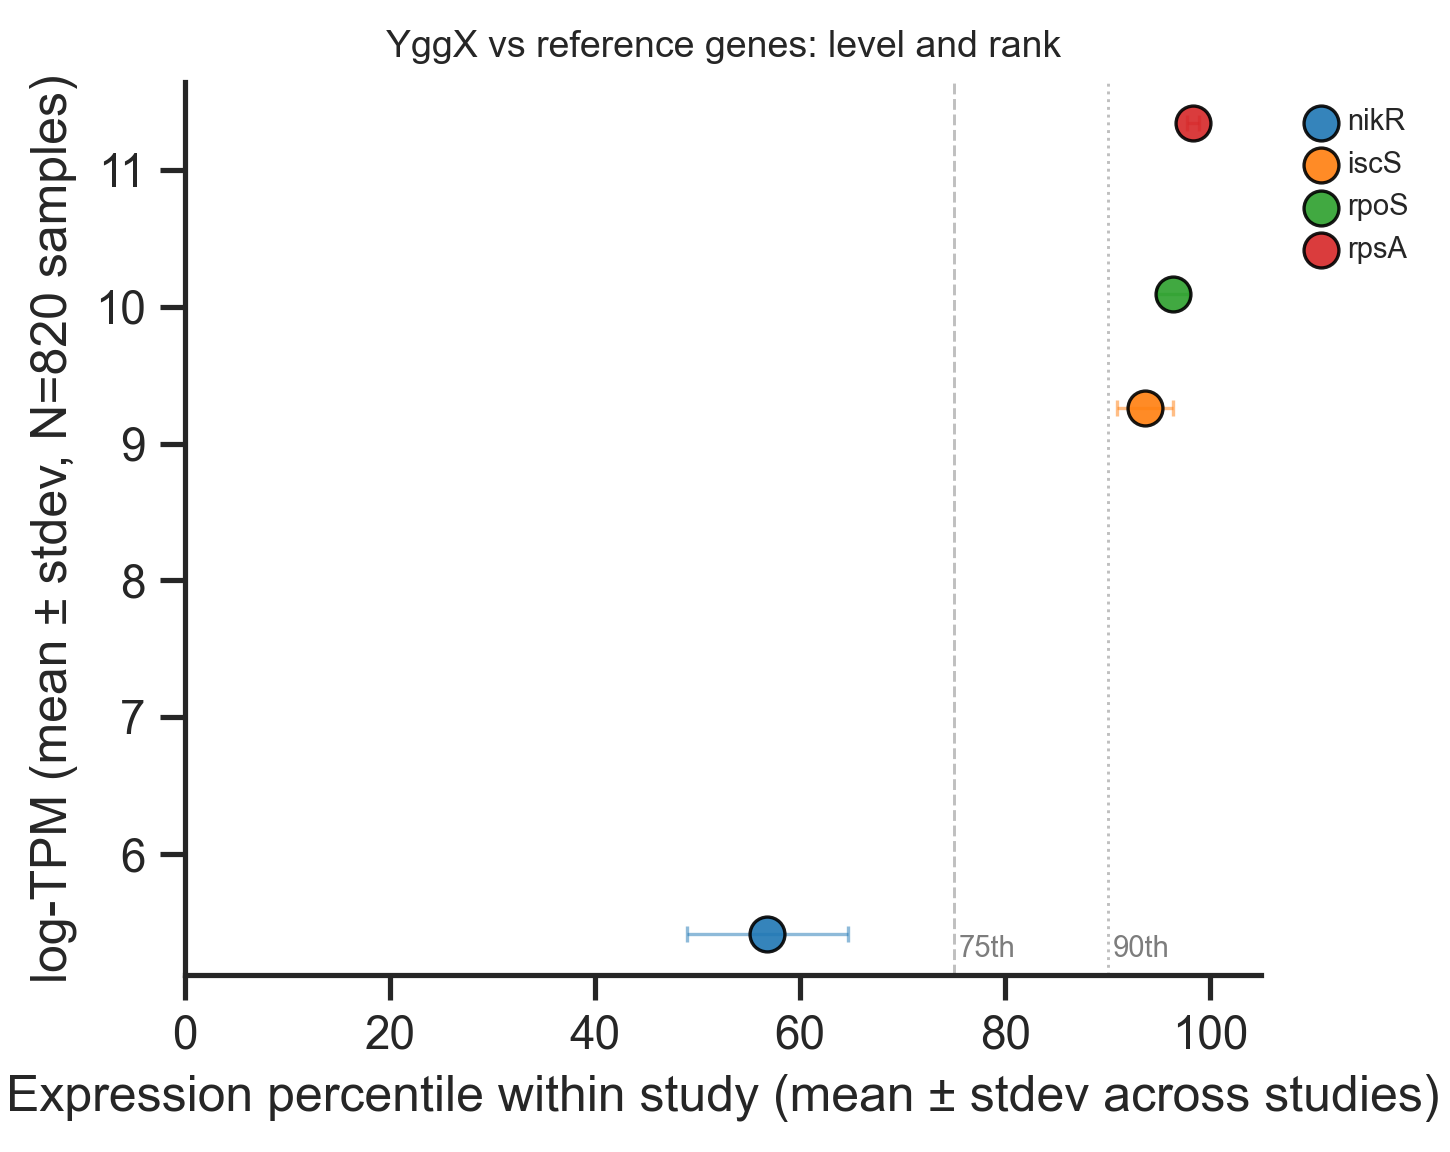

In [24]:
_panel_rows = []
for gname in _panel_ids:
    vals = _panel_long.filter(pl.col("Gene") == gname)["log_tpm"].drop_nulls().to_numpy()
    _panel_rows.append({"Gene": gname, "Mean": float(vals.mean()), "Stdev": float(vals.std())})

_panel_all_df = (
    pd.DataFrame(_panel_rows)
    .sort_values("Mean")
    .reset_index(drop=True)
    .assign(Index=lambda df: df.index.astype(float))
)

_YggX_color = "#d62728"
_ref_color = sns.color_palette("Set2")[0]

# Per-study, per-gene percentile among all genes in the full log-TPM matrix
_d_study_means = (
    d.melt(id_vars="Geneid", variable_name="Experiment", value_name="log_tpm")
    .join(m.select(["Experiment", "study"]), on="Experiment", how="left", coalesce=True)
    .group_by(["study", "Geneid"])
    .agg(pl.col("log_tpm").mean().alias("mean_expr"))
)

_pct_rows_p4 = []
for (sname,), sub in _d_study_means.group_by(["study"]):
    all_means = sub["mean_expr"].to_numpy()
    for gname, gid in _panel_ids.items():
        gene_row = sub.filter(pl.col("Geneid") == gid)
        if len(gene_row) == 0:
            continue
        gmean = float(gene_row["mean_expr"][0])
        pct = float(np.mean(all_means <= gmean) * 100)
        _pct_rows_p4.append({"Gene": gname, "Study": str(sname), "Percentile": pct})

_pct_p4_summary = (
    pd.DataFrame(_pct_rows_p4)
    .groupby("Gene")["Percentile"]
    .agg(["mean", "std"])
    .reset_index()
    .rename(columns={"mean": "PctMean", "std": "PctStdev"})
)

_plot4_df = _panel_all_df.merge(_pct_p4_summary, on="Gene")

# Distinct color per gene: YggX red, others tab10
_tab10 = sns.color_palette("tab10", 10)
_gene_color_map = {}
_ci = 0
for g in _panel_all_df["Gene"].tolist():
    if g == "YggX":
        _gene_color_map[g] = _YggX_color
    else:
        _gene_color_map[g] = _tab10[_ci % 10]
        _ci += 1

fig, ax = plt.subplots(figsize=(5, 4))

for _, row in _plot4_df.iterrows():
    c = _gene_color_map[row["Gene"]]
    ax.scatter(row["PctMean"], row["Mean"], color=c, alpha=0.9, s=70,
               edgecolors='black', linewidths=0.8, zorder=4, label=row["Gene"])
    ax.errorbar(row["PctMean"], row["Mean"],
                xerr=row["PctStdev"],
                color=c, alpha=0.5, capsize=2, capthick=0.8, elinewidth=0.8, zorder=3)

ax.axvline(75, color="gray", lw=0.7, linestyle="--", alpha=0.5)
ax.axvline(90, color="gray", lw=0.7, linestyle=":", alpha=0.5)
ax.text(75.5, 0.02, "75th", fontsize=7, alpha=0.6, transform=ax.get_xaxis_transform())
ax.text(90.5, 0.02, "90th", fontsize=7, alpha=0.6, transform=ax.get_xaxis_transform())
ax.set_xlim(0, 105)
ax.set_xlabel("Expression percentile within study (mean ± stdev across studies)")
ax.set_ylabel("log-TPM (mean ± stdev, N=820 samples)")
ax.set_title("YggX vs reference genes: level and rank", fontsize=9)
ax.legend(fontsize=7, bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False,
          handlelength=0.8, handletextpad=0.5)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(f"{_OUT}/YggX_vs_reference_genes_allsamples.svg", format='svg', bbox_inches='tight', transparent=True)
plt.savefig(f"{_OUT}/YggX_vs_reference_genes_allsamples.png", format='png', bbox_inches='tight')
plt.show()

# yggX homolog expression across pathogens (GSE152295)

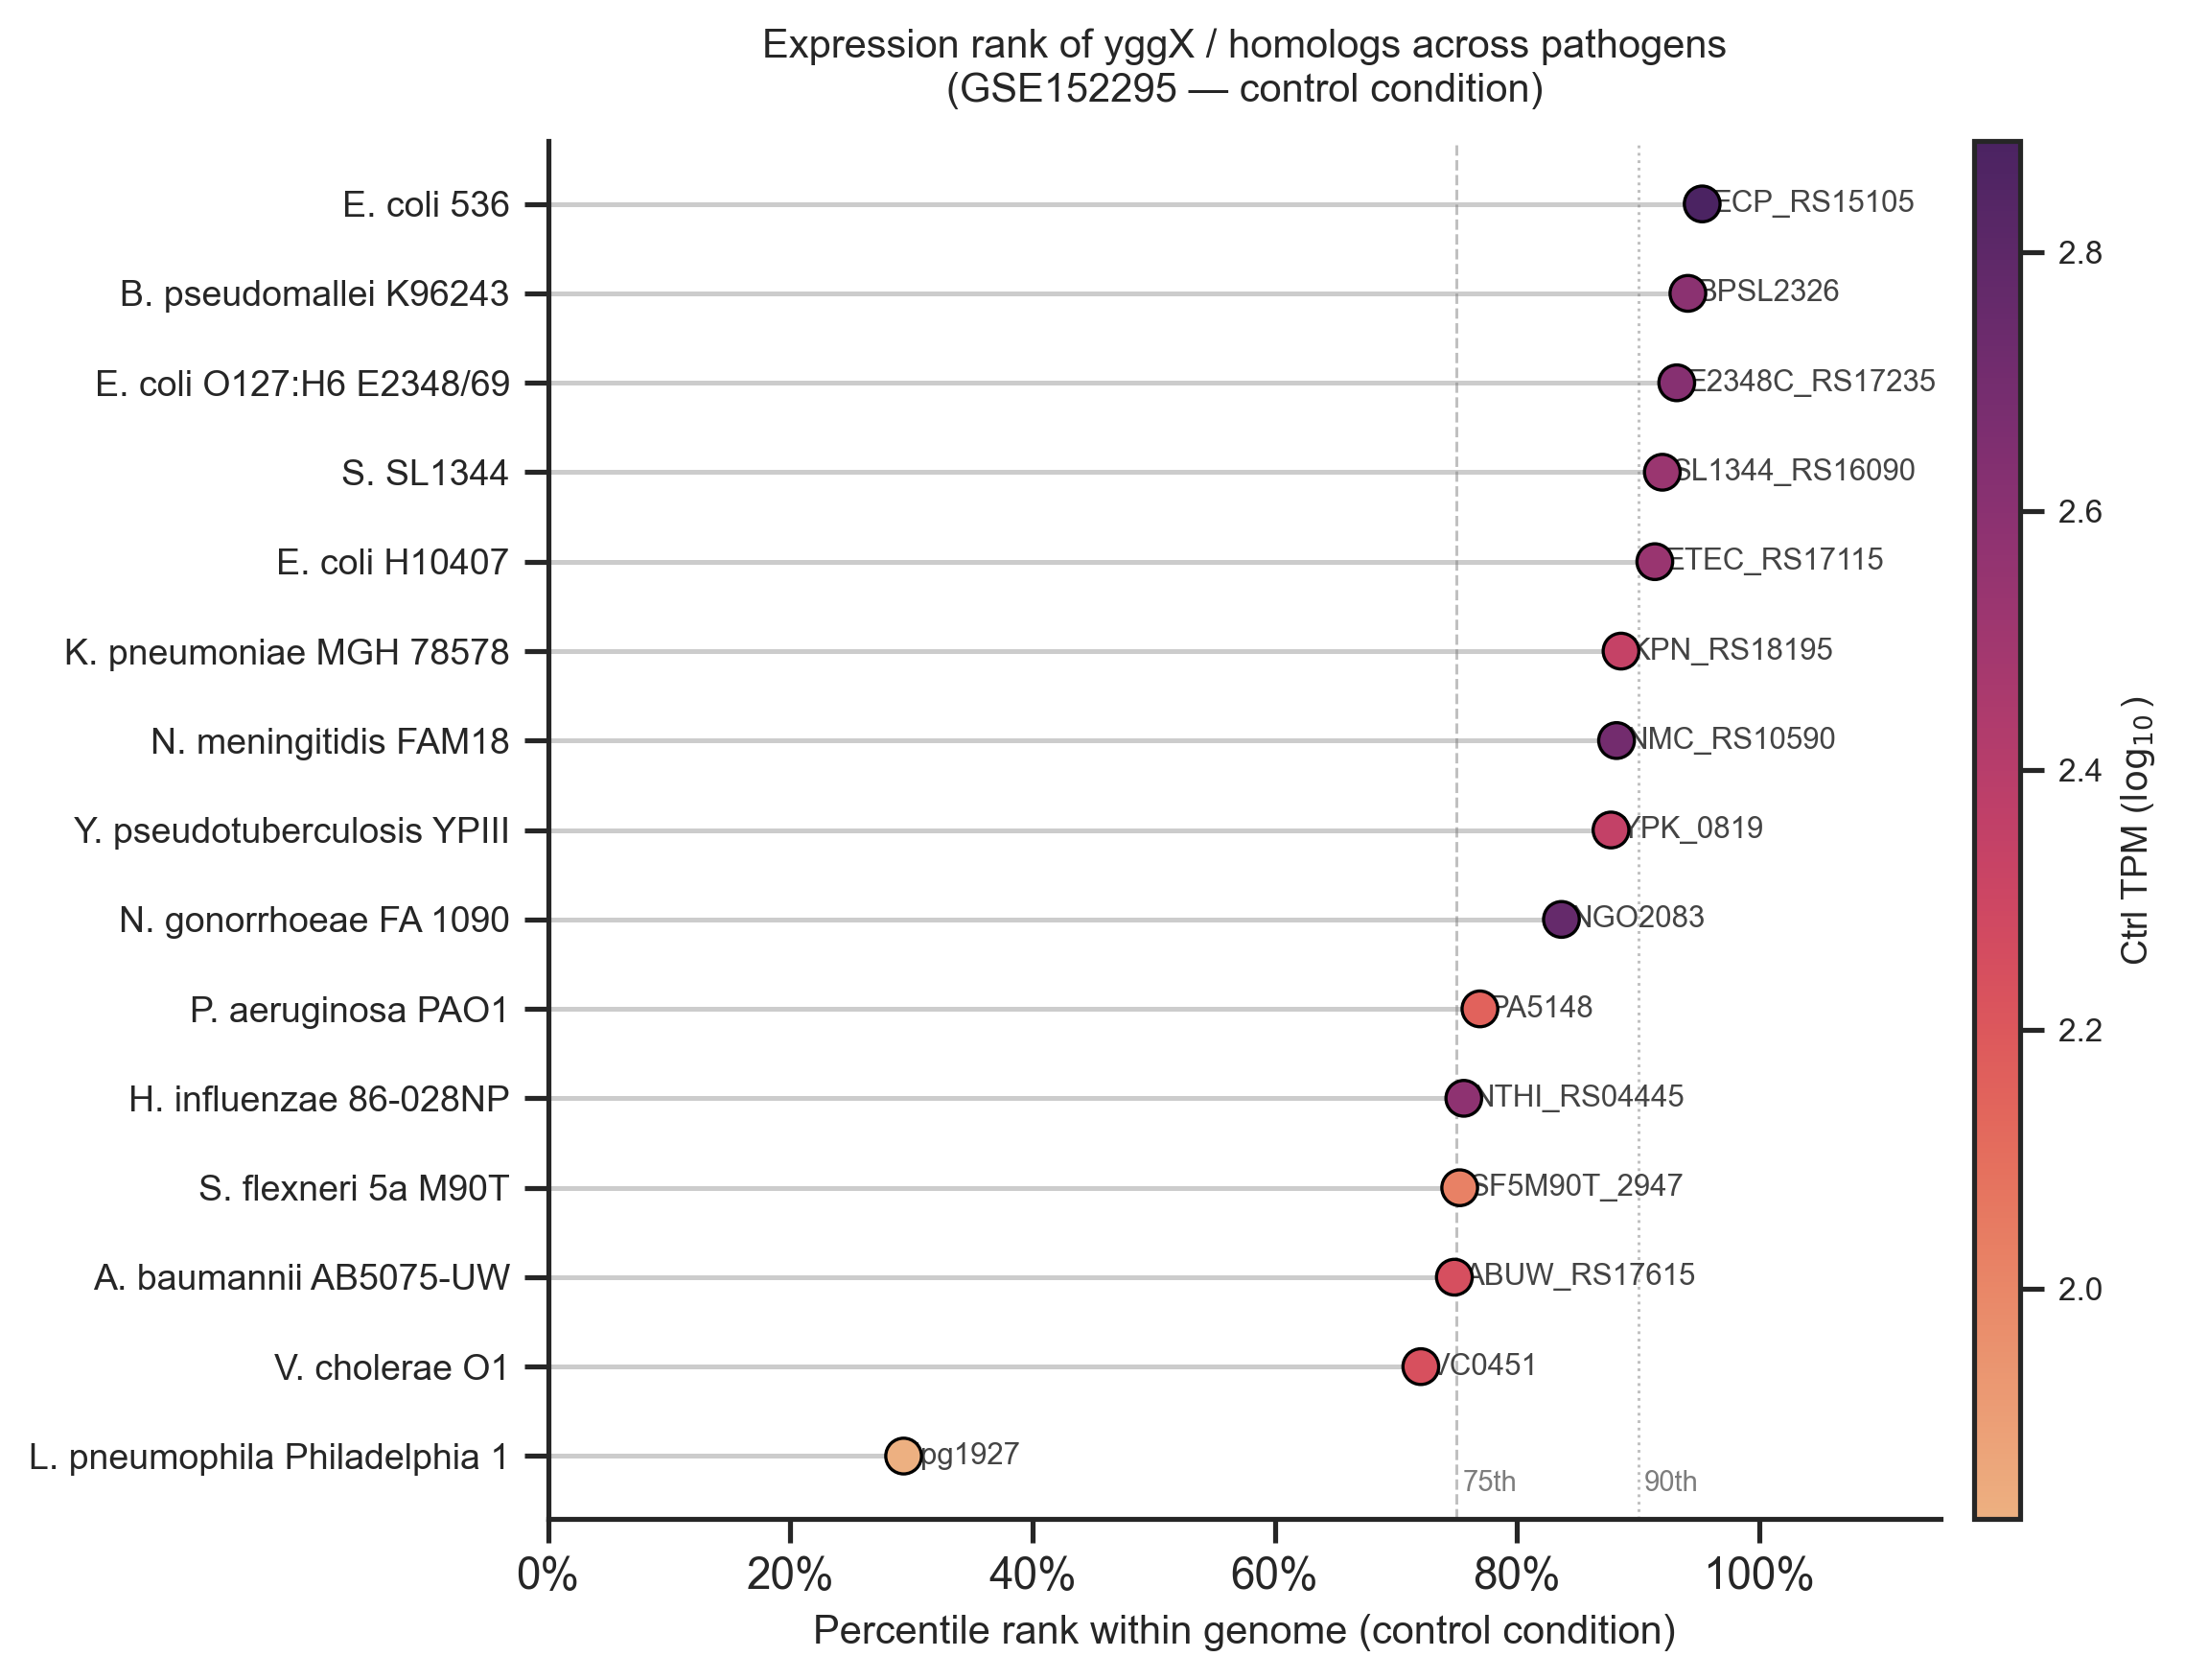

In [25]:
# --- yggX / homolog expression rank across GSE152295 pathogens (control condition) ---
# Data from the PRForm project; styled to match the panels above.
import gzip
from pathlib import Path
import matplotlib.ticker as mticker

_PRFORM   = Path("/Users/adrianjuarez/Documents/Covert_lab/repos/PRForm")
_GEO_DIR  = _PRFORM / "data" / "generated" / "gse152295"
_HITS_CSV = _PRFORM / "yggX" / "output" / "yggX_expression.csv"

_hits = pd.read_csv(_HITS_CSV)
_hits = _hits[_hits["found"] == True].copy()
_SKIP = {"subsp.", "enterica", "serovar", "str.", "strain"}


def _short_label(name):
    parts = name.split()
    keep = [w for w in parts[1:] if w.lower() not in _SKIP]
    return f"{parts[0][0]}. {' '.join(keep)}"


_records = []
for _, h in _hits.iterrows():
    with gzip.open(_GEO_DIR / f"GSE152295_{h['code']}_processed.txt.gz", "rt") as f:
        _df = pd.read_csv(f, sep="\t")
    ctrl_cols = [c for c in _df.columns if "_Ctrl_" in c and c.endswith("TPM")]
    _df["ctrl_mean"] = _df[ctrl_cols].mean(axis=1)
    _df = _df.sort_values("ctrl_mean", ascending=False).reset_index(drop=True)
    n_genes = len(_df)
    rank = int(_df[_df["Name"] == h["locus"]].index[0]) + 1  # 1-based
    _records.append({
        "label": _short_label(h["name"]),
        "locus": h["locus"],
        "pct": round(100.0 * (1 - rank / n_genes), 2),
        "ctrl_tpm": round(float(_df.loc[rank - 1, "ctrl_mean"]), 1),
    })

_rank_df = pd.DataFrame(_records).sort_values("pct").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8, 6))

# Lollipop stems
for i, row in _rank_df.iterrows():
    ax.hlines(y=i, xmin=0, xmax=row["pct"], color="#cccccc", linewidth=1.2, zorder=1)

# Dots coloured by control TPM (log10) -- warm "flare" map to echo the red YggX accent
_log_tpm = np.log10(_rank_df["ctrl_tpm"])
_sc = ax.scatter(_rank_df["pct"], range(len(_rank_df)), c=_log_tpm, cmap="flare",
                 s=80, zorder=4, edgecolors="black", linewidths=0.8)

for i, row in _rank_df.iterrows():
    ax.text(row["pct"] + 0.8, i, row["locus"], va="center", ha="left",
            fontsize=7.5, color="#444444")

_cbar = fig.colorbar(_sc, ax=ax, pad=0.02, aspect=30)
_cbar.set_label(r"Ctrl TPM ($\log_{10}$)", fontsize=9)
_cbar.ax.tick_params(labelsize=8)

ax.set_yticks(range(len(_rank_df)))
ax.set_yticklabels(_rank_df["label"], fontsize=9)
ax.set_xlabel("Percentile rank within genome (control condition)", fontsize=10)
ax.set_xlim(0, 115)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))

# 75th / 90th percentile guides -- same style as the panels above
ax.axvline(75, color="gray", lw=0.7, linestyle="--", alpha=0.5)
ax.axvline(90, color="gray", lw=0.7, linestyle=":", alpha=0.5)
ax.text(75.5, 0.02, "75th", fontsize=7, alpha=0.6, transform=ax.get_xaxis_transform())
ax.text(90.5, 0.02, "90th", fontsize=7, alpha=0.6, transform=ax.get_xaxis_transform())

ax.set_title("Expression rank of yggX / homologs across pathogens\n(GSE152295 — control condition)",
             fontsize=10, pad=10)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(f"{_OUT}/yggX_rank_plot.svg", format="svg", bbox_inches="tight", transparent=True)
plt.savefig(f"{_OUT}/yggX_rank_plot.png", format="png", dpi=150, bbox_inches="tight")
plt.show()


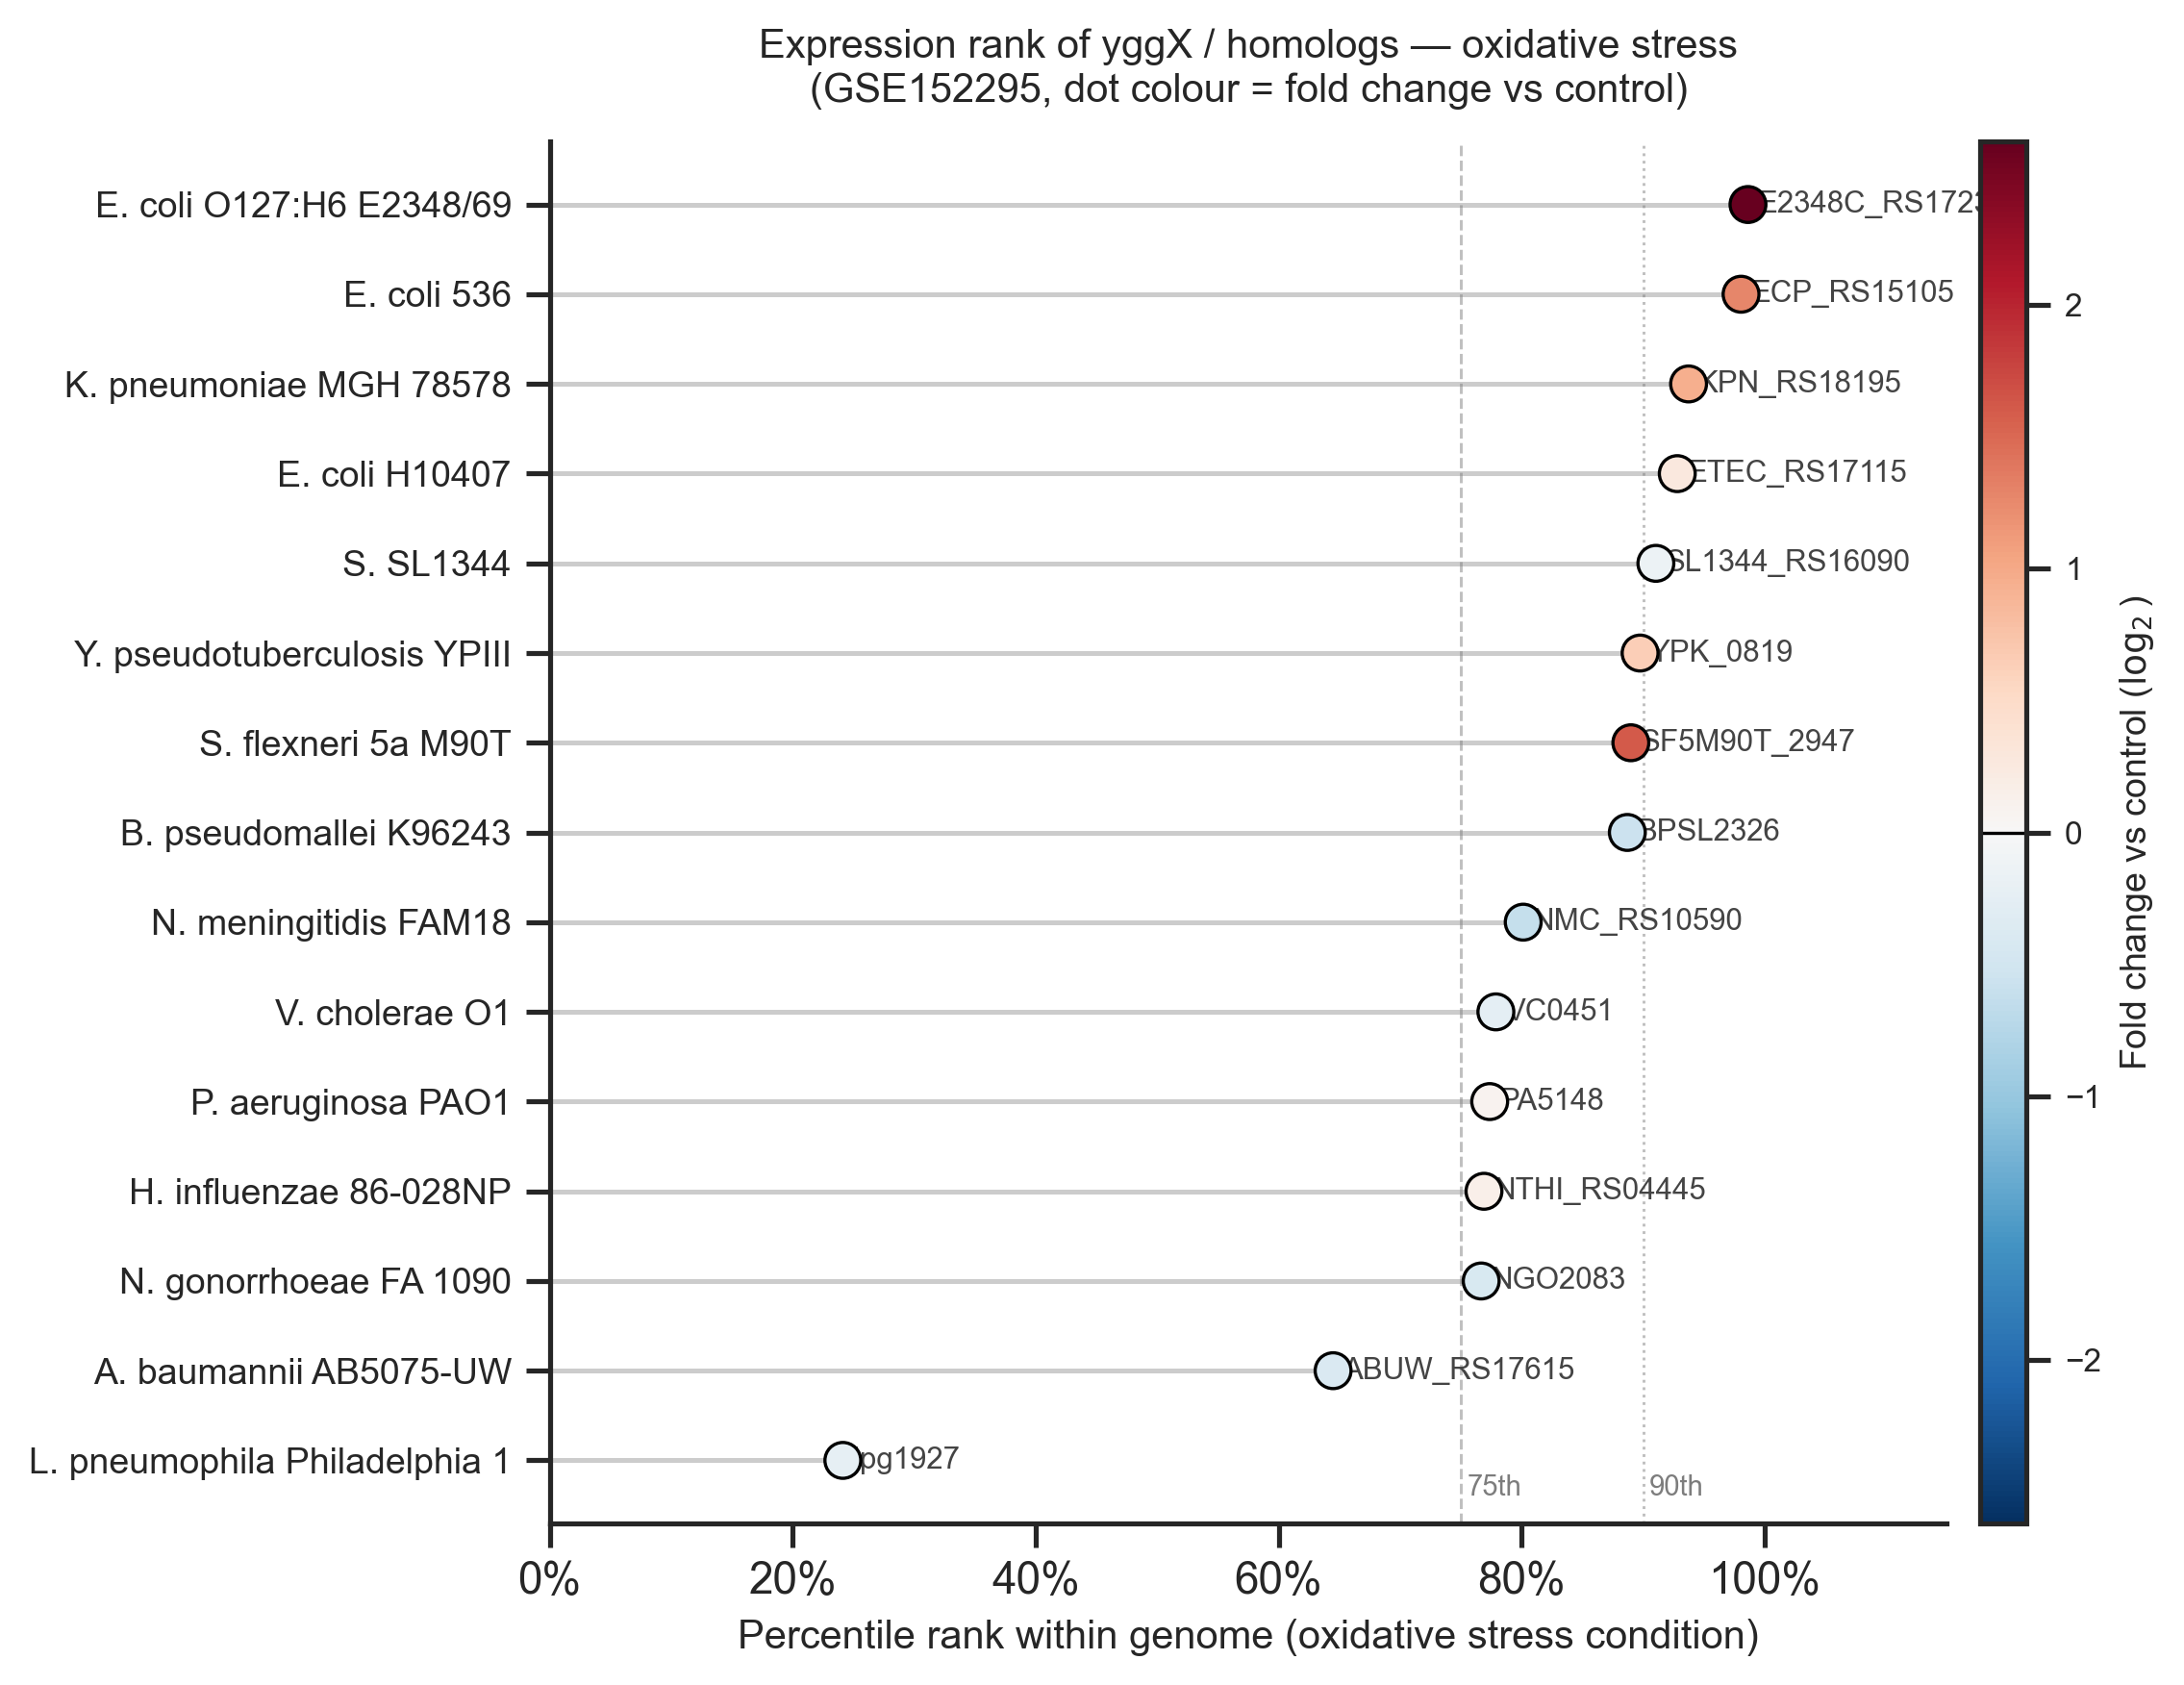

In [26]:
# --- yggX / homolog rank under oxidative stress; dot colour = log2 fold-change vs control ---
# Reuses _hits, _GEO_DIR, and _short_label defined in the control-condition cell above.
import matplotlib.colors as mcolors

_records_ox = []
for _, h in _hits.iterrows():
    with gzip.open(_GEO_DIR / f"GSE152295_{h['code']}_processed.txt.gz", "rt") as f:
        _df = pd.read_csv(f, sep="\t")
    oxs_cols = [c for c in _df.columns if "_Oxs_" in c and c.endswith("TPM")]
    if not oxs_cols:
        continue  # skip species lacking an oxidative-stress condition
    _df["oxs_mean"] = _df[oxs_cols].mean(axis=1)
    _df = _df.sort_values("oxs_mean", ascending=False).reset_index(drop=True)
    n_genes = len(_df)
    rank = int(_df[_df["Name"] == h["locus"]].index[0]) + 1
    fc = float(h["Oxs_fc"]) if "Oxs_fc" in h else np.nan
    _records_ox.append({
        "label": _short_label(h["name"]),
        "locus": h["locus"],
        "pct": round(100.0 * (1 - rank / n_genes), 2),
        "log2fc": round(np.log2(fc), 3) if fc > 0 else np.nan,
    })

_ox_df = pd.DataFrame(_records_ox).sort_values("pct").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8, 6))

# Lollipop stems
for i, row in _ox_df.iterrows():
    ax.hlines(y=i, xmin=0, xmax=row["pct"], color="#cccccc", linewidth=1.2, zorder=1)

# Diverging map centred at log2fc = 0: red = induced, blue = repressed
_fc_vals = _ox_df["log2fc"]
_abs_max = max(abs(_fc_vals.min()), abs(_fc_vals.max()), 0.5)
_norm = mcolors.TwoSlopeNorm(vmin=-_abs_max, vcenter=0, vmax=_abs_max)
_sc = ax.scatter(_ox_df["pct"], range(len(_ox_df)), c=_fc_vals, cmap="RdBu_r", norm=_norm,
                 s=80, zorder=4, edgecolors="black", linewidths=0.8)

for i, row in _ox_df.iterrows():
    ax.text(row["pct"] + 0.8, i, row["locus"], va="center", ha="left",
            fontsize=7.5, color="#444444")

_cbar = fig.colorbar(_sc, ax=ax, pad=0.02, aspect=30)
_cbar.set_label(r"Fold change vs control ($\log_2$)", fontsize=9)
_cbar.ax.tick_params(labelsize=8)
_cbar.ax.axhline(y=0, color="black", linewidth=0.8)

ax.set_yticks(range(len(_ox_df)))
ax.set_yticklabels(_ox_df["label"], fontsize=9)
ax.set_xlabel("Percentile rank within genome (oxidative stress condition)", fontsize=10)
ax.set_xlim(0, 115)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))

ax.axvline(75, color="gray", lw=0.7, linestyle="--", alpha=0.5)
ax.axvline(90, color="gray", lw=0.7, linestyle=":", alpha=0.5)
ax.text(75.5, 0.02, "75th", fontsize=7, alpha=0.6, transform=ax.get_xaxis_transform())
ax.text(90.5, 0.02, "90th", fontsize=7, alpha=0.6, transform=ax.get_xaxis_transform())

ax.set_title("Expression rank of yggX / homologs — oxidative stress\n(GSE152295, dot colour = fold change vs control)",
             fontsize=10, pad=10)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(f"{_OUT}/yggX_oxidative_plot.svg", format="svg", bbox_inches="tight", transparent=True)
plt.savefig(f"{_OUT}/yggX_oxidative_plot.png", format="png", dpi=150, bbox_inches="tight")
plt.show()
